In [1]:
# ============================================
# CELL 1: SETUP - TECHNOLOGY BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=" * 60)
print("🔧 TECHNOLOGY BAC PREDICTION SYSTEM")
print("=" * 60)
print(f"✅ Libraries loaded successfully")
print(f"📊 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🔧 Seaborn version: {sns.__version__}")
print(f"🤖 Scikit-learn imported successfully")
print(f"🟡 SHAP version: {shap.__version__}")
print("=" * 60)
print("📖 Based on BAC 2025 Technology exam - Maths Technique stream")
print("🎯 Target: Predict BAC score /20")
print("🔧 Specialties: Génie Mécanique (GM), Génie Électrique (GE), Génie Civil (GC), Génie des Procédés (GP)")
print("📐 Chapters: Mechanics (0.60), Automation (0.60), Chemistry (0.50-0.55), Civil (0.40-0.55)")
print("🧠 Problem-solving is critical across ALL specialties (0.55)")
print("=" * 60)
print("\n✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)")

🔧 TECHNOLOGY BAC PREDICTION SYSTEM
✅ Libraries loaded successfully
📊 Matplotlib version: 3.10.6
🔧 Seaborn version: 0.13.2
🤖 Scikit-learn imported successfully
🟡 SHAP version: 0.51.0
📖 Based on BAC 2025 Technology exam - Maths Technique stream
🎯 Target: Predict BAC score /20
🔧 Specialties: Génie Mécanique (GM), Génie Électrique (GE), Génie Civil (GC), Génie des Procédés (GP)
📐 Chapters: Mechanics (0.60), Automation (0.60), Chemistry (0.50-0.55), Civil (0.40-0.55)
🧠 Problem-solving is critical across ALL specialties (0.55)

✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)


In [4]:
# ============================================
# CELL 2: DATASET GENERATION - TECHNOLOGY BAC (FIXED)
# 4 Specialties: GM, GE, GC, GP (125 students each)
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_per_specialty = 125

print("=" * 60)
print("GENERATING TECHNOLOGY BAC DATASET")
print("4 Specialties: GM, GE, GC, GP (125 students each)")
print("Target: Mean ~13.2, Fail ~10%, Excellent ~15%")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution for each specialty
# ============================================

def generate_bac_scores(n):
    bac_scores = []
    # 10% failing students (6-9.9) - EXACT count
    n_fail = int(n * 0.10)
    failing = np.random.uniform(6, 9.9, n_fail)
    bac_scores.extend(failing)
    # 15% excellent students (17-20) - EXACT count
    n_excellent = int(n * 0.15)
    excellent = np.random.uniform(17, 20, n_excellent)
    bac_scores.extend(excellent)
    # Remaining average students
    n_avg = n - n_fail - n_excellent
    average = np.random.normal(13.5, 1.5, n_avg)
    average = np.clip(average, 10, 16.9)
    bac_scores.extend(average)
    bac_scores = np.array(bac_scores)
    np.random.shuffle(bac_scores)
    return np.round(bac_scores, 1)

all_data = []
specialties = ['GM', 'GE', 'GC', 'GP']

for specialty in specialties:
    n = n_per_specialty
    bac_scores = generate_bac_scores(n)
    bac_mean = bac_scores.mean()
    bac_std = bac_scores.std()
    bac_scaled = (bac_scores - bac_mean) / bac_std
    
    print(f"\n📊 Generating {specialty} students (n={n})")
    print(f"   BAC Mean: {bac_mean:.2f}, Std: {bac_std:.2f}")
    
    # ============================================
    # Function to generate feature with exact correlation
    # ============================================
    def generate_feature(bac_scaled, target_corr, target_mean, target_std):
        signal = target_corr * bac_scaled * target_std
        noise_std = target_std * np.sqrt(max(0.01, 1 - target_corr**2))
        noise = np.random.normal(0, noise_std, n)
        feature = target_mean + signal + noise
        return feature
    
    # ============================================
    # Academic History (All specialties)
    # ============================================
    tech_avg_grade = generate_feature(bac_scaled, 0.70, 13.0, 2.2)
    tech_avg_grade = np.clip(tech_avg_grade, 8, 19.5).round(1)
    
    tech_grade_t3 = tech_avg_grade + np.random.normal(0.3, 0.8, n)
    tech_grade_t3 = np.clip(tech_grade_t3, 8, 19.5).round(1)
    
    tech_grade_t2 = tech_avg_grade + np.random.normal(0, 0.9, n)
    tech_grade_t2 = np.clip(tech_grade_t2, 8, 19.5).round(1)
    
    tech_grade_t1 = tech_avg_grade - np.random.normal(0.5, 1.0, n)
    tech_grade_t1 = np.clip(tech_grade_t1, 8, 19.5).round(1)
    
    tech_trend = tech_grade_t3 - tech_grade_t1
    
    # ============================================
    # Cross-Specialty Skills (All specialties)
    # ============================================
    problem_solving = generate_feature(bac_scaled, 0.55, 6.3, 1.6)
    problem_solving = np.clip(problem_solving, 2, 10).round(1)
    
    diagram_interpretation = generate_feature(bac_scaled, 0.50, 6.2, 1.6)
    diagram_interpretation = np.clip(diagram_interpretation, 2, 10).round(1)
    
    calculation_accuracy = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
    calculation_accuracy = np.clip(calculation_accuracy, 2, 10).round(1)
    
    technical_drawing = generate_feature(bac_scaled, 0.40, 5.8, 1.7)
    technical_drawing = np.clip(technical_drawing, 2, 10).round(1)
    
    # ============================================
    # Practice & Preparation (All specialties)
    # ============================================
    bac_exams_practiced_raw = generate_feature(bac_scaled, 0.40, 8, 5)
    bac_exams_practiced = np.clip(bac_exams_practiced_raw, 0, 30).round(0).astype(int)
    
    specialty_exercises_week_raw = generate_feature(bac_scaled, 0.35, 5, 3)
    specialty_exercises_week = np.clip(specialty_exercises_week_raw, 0, 15).round(0).astype(int)
    
    full_simulations_raw = generate_feature(bac_scaled, 0.35, 2, 1.5)
    full_simulations = np.clip(full_simulations_raw, 0, 5).round(0).astype(int)
    
    correction_quality = generate_feature(bac_scaled, 0.25, 6, 2)
    correction_quality = np.clip(correction_quality, 2, 10).round(1)
    
    # ============================================
    # Psychological Factors (All specialties)
    # ============================================
    tech_anxiety = generate_feature(bac_scaled, -0.40, 6.0, 2.0)
    tech_anxiety = np.clip(tech_anxiety, 2, 10).round(1)
    
    confidence = generate_feature(bac_scaled, 0.35, 6.0, 1.8)
    confidence = np.clip(confidence, 2, 10).round(1)
    
    exam_stress = generate_feature(bac_scaled, -0.30, 5.5, 2.0)
    exam_stress = np.clip(exam_stress, 2, 10).round(1)
    
    focus_concentration = generate_feature(bac_scaled, 0.30, 6.0, 1.7)
    focus_concentration = np.clip(focus_concentration, 2, 10).round(1)
    
    # ============================================
    # Study Behavior (All specialties)
    # ============================================
    study_hours = generate_feature(bac_scaled, 0.25, 5, 2)
    study_hours = np.clip(study_hours, 2, 12).round(1)
    
    consistency = generate_feature(bac_scaled, 0.30, 6, 2)
    consistency = np.clip(consistency, 2, 10).round(1)
    
    teacher_quality = generate_feature(bac_scaled, 0.20, 6, 1.8)
    teacher_quality = np.clip(teacher_quality, 2, 10).round(1)
    
    lab_access = generate_feature(bac_scaled, 0.15, 5, 2)
    lab_access = np.clip(lab_access, 2, 10).round(1)
    
    tutoring = np.random.choice([0,1], n, p=[0.85, 0.15])
    
    # ============================================
    # SPECIALTY-SPECIFIC FEATURES
    # Set to 0 for non-relevant specialties
    # ============================================
    
    # Initialize with zeros
    mechanics_rdm = np.zeros(n)
    material_resistance = np.zeros(n)
    gear_transmission = np.zeros(n)
    automation_grafcet = np.zeros(n)
    logic_circuits = np.zeros(n)
    electrical_systems = np.zeros(n)
    structural_analysis = np.zeros(n)
    reinforced_concrete = np.zeros(n)
    road_construction = np.zeros(n)
    organic_chemistry = np.zeros(n)
    polymer_chemistry = np.zeros(n)
    thermodynamics = np.zeros(n)
    
    # Fill based on specialty
    if specialty == 'GM':
        mechanics_rdm = generate_feature(bac_scaled, 0.60, 6.5, 1.6)
        mechanics_rdm = np.clip(mechanics_rdm, 2, 10).round(1)
        material_resistance = generate_feature(bac_scaled, 0.55, 6.2, 1.6)
        material_resistance = np.clip(material_resistance, 2, 10).round(1)
        gear_transmission = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
        gear_transmission = np.clip(gear_transmission, 2, 10).round(1)
        print(f"   ✅ GM features generated")
        
    elif specialty == 'GE':
        automation_grafcet = generate_feature(bac_scaled, 0.60, 6.5, 1.6)
        automation_grafcet = np.clip(automation_grafcet, 2, 10).round(1)
        logic_circuits = generate_feature(bac_scaled, 0.55, 6.2, 1.6)
        logic_circuits = np.clip(logic_circuits, 2, 10).round(1)
        electrical_systems = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
        electrical_systems = np.clip(electrical_systems, 2, 10).round(1)
        print(f"   ✅ GE features generated")
        
    elif specialty == 'GC':
        structural_analysis = generate_feature(bac_scaled, 0.55, 6.3, 1.6)
        structural_analysis = np.clip(structural_analysis, 2, 10).round(1)
        reinforced_concrete = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
        reinforced_concrete = np.clip(reinforced_concrete, 2, 10).round(1)
        road_construction = generate_feature(bac_scaled, 0.40, 5.8, 1.8)
        road_construction = np.clip(road_construction, 2, 10).round(1)
        print(f"   ✅ GC features generated")
        
    elif specialty == 'GP':
        organic_chemistry = generate_feature(bac_scaled, 0.55, 6.3, 1.6)
        organic_chemistry = np.clip(organic_chemistry, 2, 10).round(1)
        polymer_chemistry = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
        polymer_chemistry = np.clip(polymer_chemistry, 2, 10).round(1)
        thermodynamics = generate_feature(bac_scaled, 0.45, 5.8, 1.8)
        thermodynamics = np.clip(thermodynamics, 2, 10).round(1)
        print(f"   ✅ GP features generated")
    
    # ============================================
    # Derived Features
    # ============================================
    mechanics_block = (mechanics_rdm + material_resistance + gear_transmission) / 3
    automation_block = (automation_grafcet + logic_circuits + electrical_systems) / 3
    chemistry_block = (organic_chemistry + polymer_chemistry + thermodynamics) / 3
    civil_block = (structural_analysis + reinforced_concrete + road_construction) / 3
    
    skill_blocks = np.array([mechanics_block, automation_block, chemistry_block, civil_block])
    imbalance_score = np.zeros(n)
    for i in range(n):
        non_zero_blocks = [skill_blocks[j][i] for j in range(4) if skill_blocks[j][i] > 0]
        if len(non_zero_blocks) > 1:
            imbalance_score[i] = np.var(non_zero_blocks)
        else:
            imbalance_score[i] = 0
    imbalance_score = np.round(imbalance_score, 2)
    
    practice_intensity = (bac_exams_practiced / 30 * 10 + specialty_exercises_week / 15 * 10 + full_simulations / 5 * 10) / 3
    practice_intensity = practice_intensity.round(1)
    
    psychological_composite = (confidence + focus_concentration + (10 - tech_anxiety) + (10 - exam_stress)) / 4
    psychological_composite = psychological_composite.round(1)
    
    # ============================================
    # Store data for this specialty
    # ============================================
    specialty_data = pd.DataFrame({
        'specialty': [specialty] * n,
        'tech_grade_t1': tech_grade_t1,
        'tech_grade_t2': tech_grade_t2,
        'tech_grade_t3': tech_grade_t3,
        'tech_avg_grade': tech_avg_grade,
        'tech_trend': tech_trend.round(1),
        'mechanics_rdm': mechanics_rdm,
        'material_resistance': material_resistance,
        'gear_transmission': gear_transmission,
        'automation_grafcet': automation_grafcet,
        'logic_circuits': logic_circuits,
        'electrical_systems': electrical_systems,
        'structural_analysis': structural_analysis,
        'reinforced_concrete': reinforced_concrete,
        'road_construction': road_construction,
        'organic_chemistry': organic_chemistry,
        'polymer_chemistry': polymer_chemistry,
        'thermodynamics': thermodynamics,
        'problem_solving': problem_solving,
        'diagram_interpretation': diagram_interpretation,
        'calculation_accuracy': calculation_accuracy,
        'technical_drawing': technical_drawing,
        'bac_exams_practiced': bac_exams_practiced,
        'specialty_exercises_week': specialty_exercises_week,
        'full_simulations': full_simulations,
        'correction_quality': correction_quality,
        'tech_anxiety': tech_anxiety,
        'confidence': confidence,
        'exam_stress': exam_stress,
        'focus_concentration': focus_concentration,
        'study_hours': study_hours,
        'consistency': consistency,
        'teacher_quality': teacher_quality,
        'lab_access': lab_access,
        'tutoring': tutoring,
        'mechanics_block': mechanics_block.round(1),
        'automation_block': automation_block.round(1),
        'chemistry_block': chemistry_block.round(1),
        'civil_block': civil_block.round(1),
        'imbalance_score': imbalance_score,
        'practice_intensity': practice_intensity,
        'psychological_composite': psychological_composite,
        'bac_score_technology': bac_scores
    })
    
    all_data.append(specialty_data)

# ============================================
# Combine all specialties
# ============================================
df = pd.concat(all_data, ignore_index=True)

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Total Students: {len(df)}")
print(f"   Features: {len(df.columns)}")
print(f"   Target: bac_score_technology")

print("\n📊 STUDENTS PER SPECIALTY:")
for specialty in specialties:
    count = (df['specialty'] == specialty).sum()
    print(f"   {specialty}: {count} students")

print("\n📊 VERIFICATION - ACTUAL CORRELATIONS WITH BAC SCORE:")
print("-" * 65)

key_features = [
    ('tech_avg_grade', 0.70),
    ('problem_solving', 0.55),
    ('diagram_interpretation', 0.50),
    ('calculation_accuracy', 0.45),
    ('bac_exams_practiced', 0.40),
    ('tech_anxiety', -0.40),
    ('confidence', 0.35),
    ('practice_intensity', 0.38)
]

for feature, target in key_features:
    if feature in df.columns:
        actual = np.corrcoef(df['bac_score_technology'], df[feature])[0,1]
        status = "✅" if abs(actual - target) < 0.08 else "⚠️" if abs(actual - target) < 0.12 else "❌"
        print(f"   {feature:<25} actual: {actual:>6.3f} target: {target:>5.2f} {status}")

print("\n📊 SPECIALTY-SPECIFIC CORRELATIONS:")

for specialty in specialties:
    df_spec = df[df['specialty'] == specialty]
    print(f"\n   {specialty}:")
    if specialty == 'GM':
        for f in ['mechanics_rdm', 'material_resistance', 'gear_transmission']:
            if f in df_spec.columns:
                actual = np.corrcoef(df_spec['bac_score_technology'], df_spec[f])[0,1]
                print(f"      {f}: {actual:.3f}")
    elif specialty == 'GE':
        for f in ['automation_grafcet', 'logic_circuits', 'electrical_systems']:
            if f in df_spec.columns:
                actual = np.corrcoef(df_spec['bac_score_technology'], df_spec[f])[0,1]
                print(f"      {f}: {actual:.3f}")
    elif specialty == 'GC':
        for f in ['structural_analysis', 'reinforced_concrete', 'road_construction']:
            if f in df_spec.columns:
                actual = np.corrcoef(df_spec['bac_score_technology'], df_spec[f])[0,1]
                print(f"      {f}: {actual:.3f}")
    elif specialty == 'GP':
        for f in ['organic_chemistry', 'polymer_chemistry', 'thermodynamics']:
            if f in df_spec.columns:
                actual = np.corrcoef(df_spec['bac_score_technology'], df_spec[f])[0,1]
                print(f"      {f}: {actual:.3f}")

print("\n📊 FINAL BAC SCORE DISTRIBUTION:")
print(f"   Mean: {df['bac_score_technology'].mean():.2f}/20")
print(f"   Std: {df['bac_score_technology'].std():.2f}")
print(f"   Fail (<10): {(df['bac_score_technology'] < 10).sum()} ({(df['bac_score_technology'] < 10).sum()/len(df)*100:.1f}%)")
print(f"   Excellent (17-20): {(df['bac_score_technology'] >= 17).sum()} ({(df['bac_score_technology'] >= 17).sum()/len(df)*100:.1f}%)")

print("\n📊 First 10 rows preview:")
print(df[['specialty', 'bac_score_technology', 'problem_solving', 'tech_anxiety']].head(10))

print("\n" + "=" * 60)
print("✅ Cell 2 complete! Ready for Cell 3")
print("=" * 60)

GENERATING TECHNOLOGY BAC DATASET
4 Specialties: GM, GE, GC, GP (125 students each)
Target: Mean ~13.2, Fail ~10%, Excellent ~15%

📊 Generating GM students (n=125)
   BAC Mean: 13.59, Std: 2.76
   ✅ GM features generated

📊 Generating GE students (n=125)
   BAC Mean: 13.78, Std: 2.75
   ✅ GE features generated

📊 Generating GC students (n=125)
   BAC Mean: 13.46, Std: 2.90
   ✅ GC features generated

📊 Generating GP students (n=125)
   BAC Mean: 13.62, Std: 3.04
   ✅ GP features generated

✅ FINAL DATASET GENERATED
   Total Students: 500
   Features: 43
   Target: bac_score_technology

📊 STUDENTS PER SPECIALTY:
   GM: 125 students
   GE: 125 students
   GC: 125 students
   GP: 125 students

📊 VERIFICATION - ACTUAL CORRELATIONS WITH BAC SCORE:
-----------------------------------------------------------------
   tech_avg_grade            actual:  0.702 target:  0.70 ✅
   problem_solving           actual:  0.524 target:  0.55 ✅
   diagram_interpretation    actual:  0.562 target:  0.50 ✅
 

In [5]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("technology_bac_dataset.csv", index=False)

print("✅ Dataset saved: technology_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_technology'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_technology'].min():.1f} - {df['bac_score_technology'].max():.1f}")

✅ Dataset saved: technology_bac_dataset.csv
📊 Shape: (500, 43)
🎯 BAC Score mean: 13.61/20
📈 BAC Score range: 6.1 - 20.0


In [6]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

df = pd.read_csv("technology_bac_dataset.csv")

print("✅ Dataset loaded: technology_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_technology'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_technology'].min():.1f} - {df['bac_score_technology'].max():.1f}")

✅ Dataset loaded: technology_bac_dataset.csv
📊 Shape: (500, 43)
🎯 BAC Score mean: 13.61/20
📈 BAC Score range: 6.1 - 20.0


In [7]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - TECHNOLOGY BAC")
print("="*60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(df.isnull().sum().sum())
print(f"✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Predictors: {df.shape[1] - 1}")
print(f"Target: 1 (bac_score_technology)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

print("\n8️⃣ SPECIALTY DISTRIBUTION:")
print(df['specialty'].value_counts())

📊 EXPLORATORY DATA ANALYSIS - TECHNOLOGY BAC

1️⃣ FIRST 5 ROWS:
  specialty  tech_grade_t1  tech_grade_t2  tech_grade_t3  tech_avg_grade  \
0        GM           11.7           11.4           10.9            11.8   
1        GM           14.8           14.0           15.4            15.8   
2        GM           15.1           18.1           16.9            16.3   
3        GM           14.2           13.2           13.6            13.4   
4        GM            9.4           10.1            9.7             9.6   

   tech_trend  mechanics_rdm  material_resistance  gear_transmission  \
0        -0.8            9.5                  5.0                5.2   
1         0.6            6.5                  8.7                8.6   
2         1.8            9.3                  7.2                7.1   
3        -0.6            8.9                  4.0                6.4   
4         0.3            5.3                  5.0                3.6   

   automation_grafcet  logic_circuits  electri

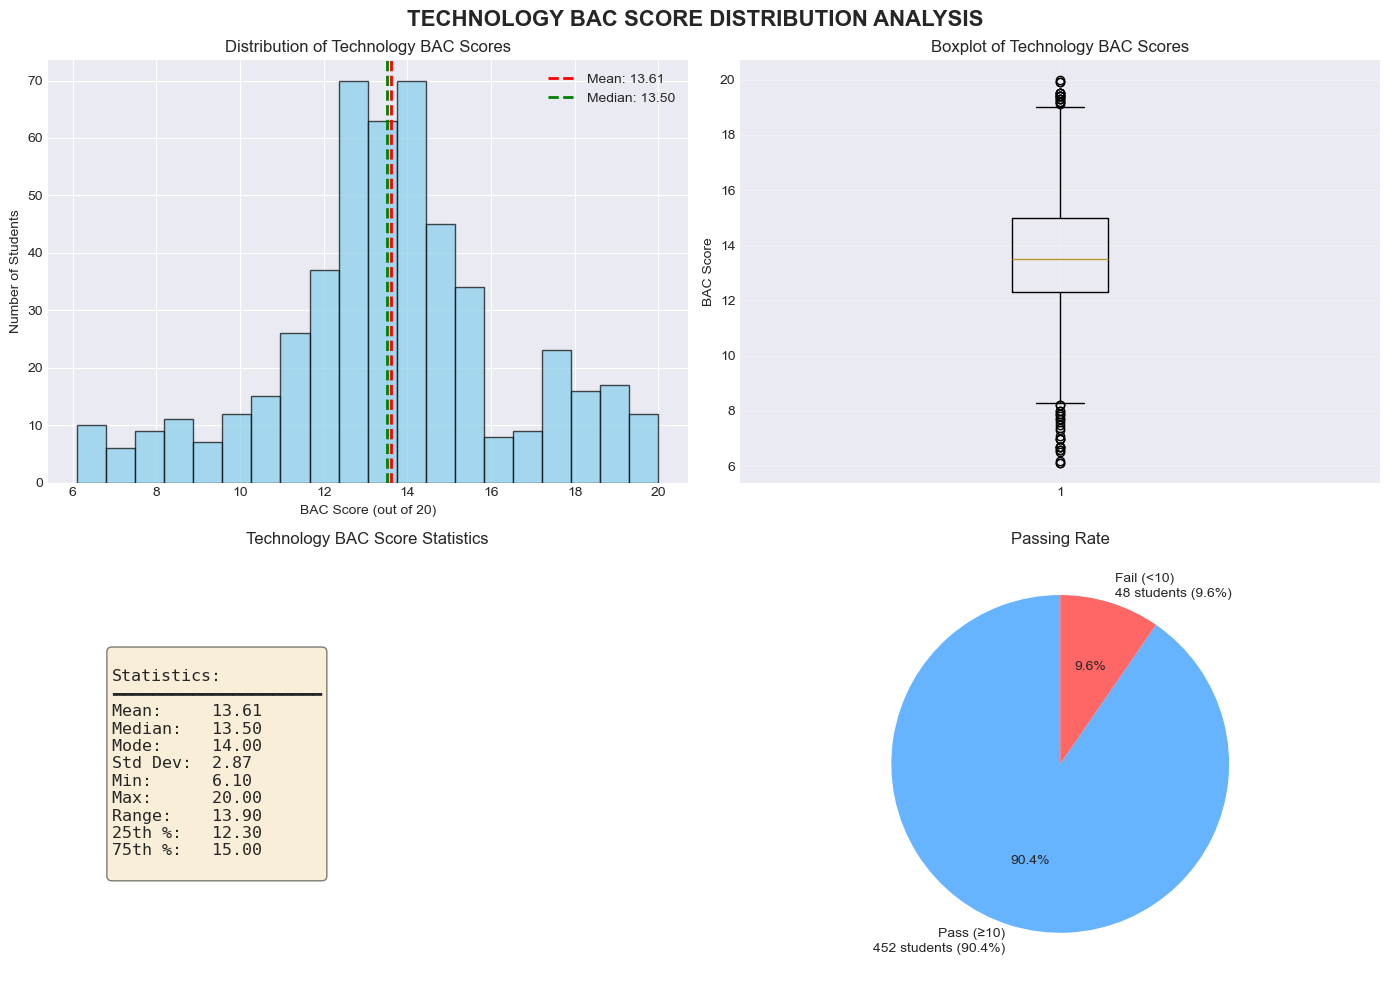


📊 TECHNOLOGY BAC SCORE DISTRIBUTION SUMMARY
   Mean BAC Score:     13.61/20
   Median BAC Score:   13.50/20
   Standard Deviation: 2.87
   Pass Rate (≥10):    90.4% (452/500 students)
   Fail Rate (<10):    9.6% (48/500 students)

📊 BAC SCORE BY SPECIALTY:
   GM: Mean=13.59, Std=2.78, Min=6.1, Max=19.5
   GE: Mean=13.78, Std=2.76, Min=6.7, Max=19.4
   GC: Mean=13.46, Std=2.91, Min=6.1, Max=19.9
   GP: Mean=13.62, Std=3.05, Min=6.5, Max=20.0


In [8]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of BAC scores
axes[0,0].hist(df['bac_score_technology'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score_technology'].mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {df["bac_score_technology"].mean():.2f}')
axes[0,0].axvline(df['bac_score_technology'].median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {df["bac_score_technology"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of Technology BAC Scores')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score_technology'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of Technology BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score_technology'].mean():.2f}
Median:   {df['bac_score_technology'].median():.2f}
Mode:     {df['bac_score_technology'].mode().iloc[0]:.2f}
Std Dev:  {df['bac_score_technology'].std():.2f}
Min:      {df['bac_score_technology'].min():.2f}
Max:      {df['bac_score_technology'].max():.2f}
Range:    {df['bac_score_technology'].max() - df['bac_score_technology'].min():.2f}
25th %:   {df['bac_score_technology'].quantile(0.25):.2f}
75th %:   {df['bac_score_technology'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('Technology BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score_technology'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('TECHNOLOGY BAC SCORE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 TECHNOLOGY BAC SCORE DISTRIBUTION SUMMARY")
print("="*60)
print(f"   Mean BAC Score:     {df['bac_score_technology'].mean():.2f}/20")
print(f"   Median BAC Score:   {df['bac_score_technology'].median():.2f}/20")
print(f"   Standard Deviation: {df['bac_score_technology'].std():.2f}")
print(f"   Pass Rate (≥10):    {passing/len(df)*100:.1f}% ({passing}/{len(df)} students)")
print(f"   Fail Rate (<10):    {failing/len(df)*100:.1f}% ({failing}/{len(df)} students)")
print("="*60)

# Additional: BAC distribution by specialty
print("\n📊 BAC SCORE BY SPECIALTY:")
print("="*60)
for specialty in df['specialty'].unique():
    spec_data = df[df['specialty'] == specialty]['bac_score_technology']
    print(f"   {specialty}: Mean={spec_data.mean():.2f}, Std={spec_data.std():.2f}, Min={spec_data.min():.1f}, Max={spec_data.max():.1f}")
print("="*60)


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score_technology               : 1.000
   tech_avg_grade                     : 0.702
   tech_grade_t3                      : 0.661
   tech_grade_t1                      : 0.650
   tech_grade_t2                      : 0.632
   psychological_composite            : 0.620
   diagram_interpretation             : 0.562
   practice_intensity                 : 0.530
   problem_solving                    : 0.524
   technical_drawing                  : 0.467
   bac_exams_practiced                : 0.428
   calculation_accuracy               : 0.396
   focus_concentration                : 0.352
   confidence                         : 0.347
   full_simulations                   : 0.335
   correction_quality                 : 0.304
   specialty_exercises_week           : 0.300
   consistency                        : 0.286
   study_hours                        : 0.271
   teacher_quality                    : 0.172
   lab_access                

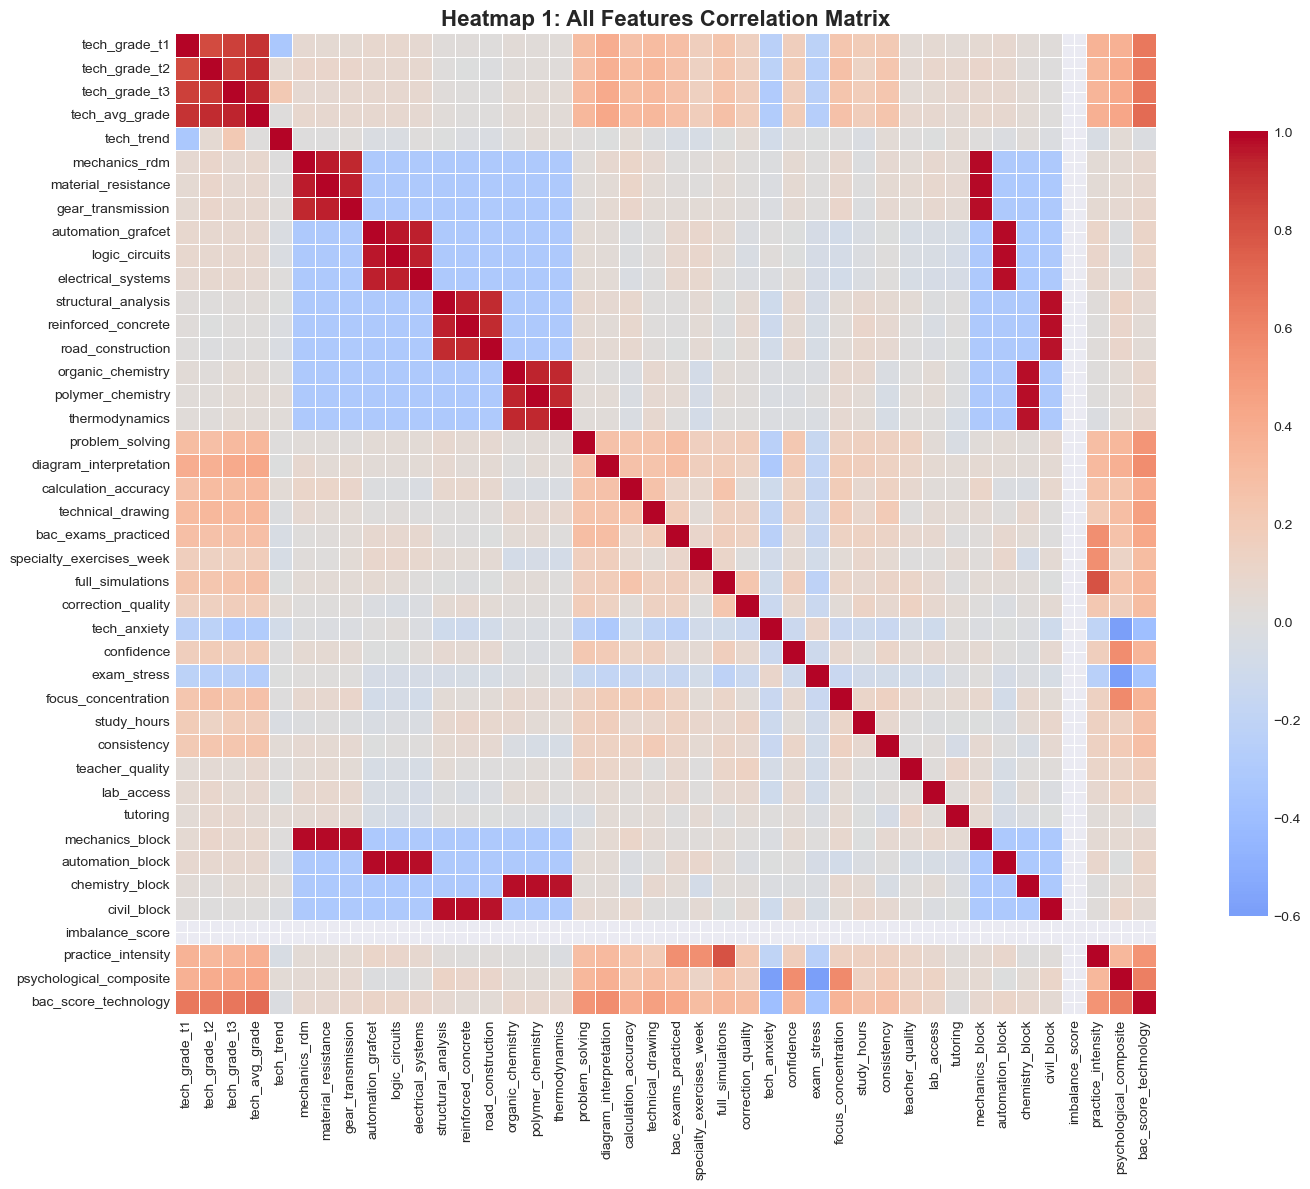


📊 HEATMAP 2: Top 15 Features Correlated with BAC Score


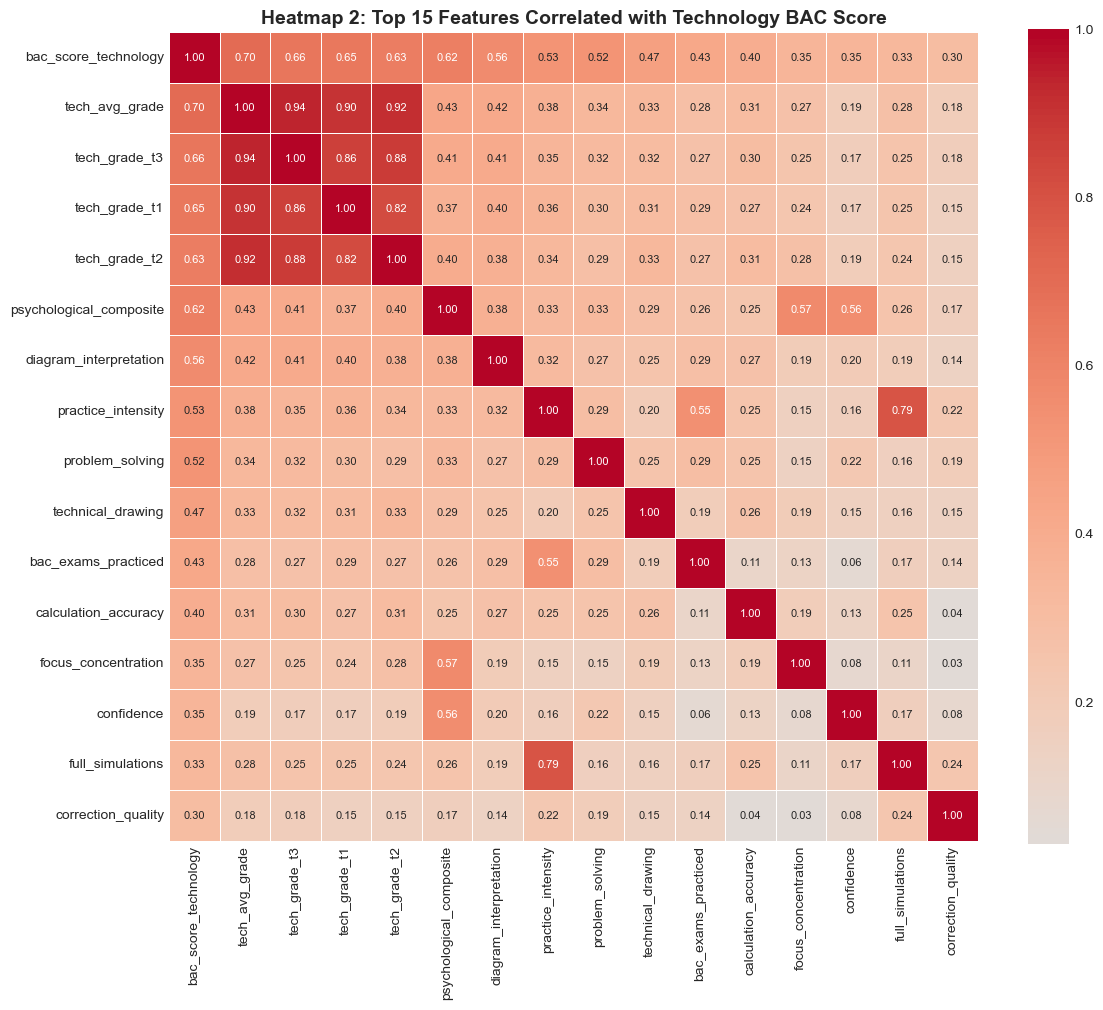


📊 HEATMAP 3: Cross-Specialty Skills Correlation


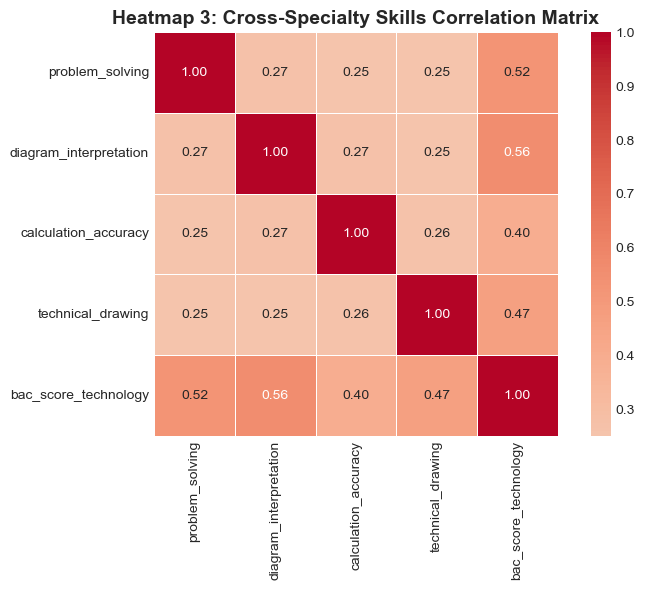


📋 Cross-specialty skills correlation with BAC Score:
   • problem_solving: correlation = 0.524
   • diagram_interpretation: correlation = 0.562
   • calculation_accuracy: correlation = 0.396
   • technical_drawing: correlation = 0.467

📊 HEATMAP 4: Psychological & Practice Factors Correlation


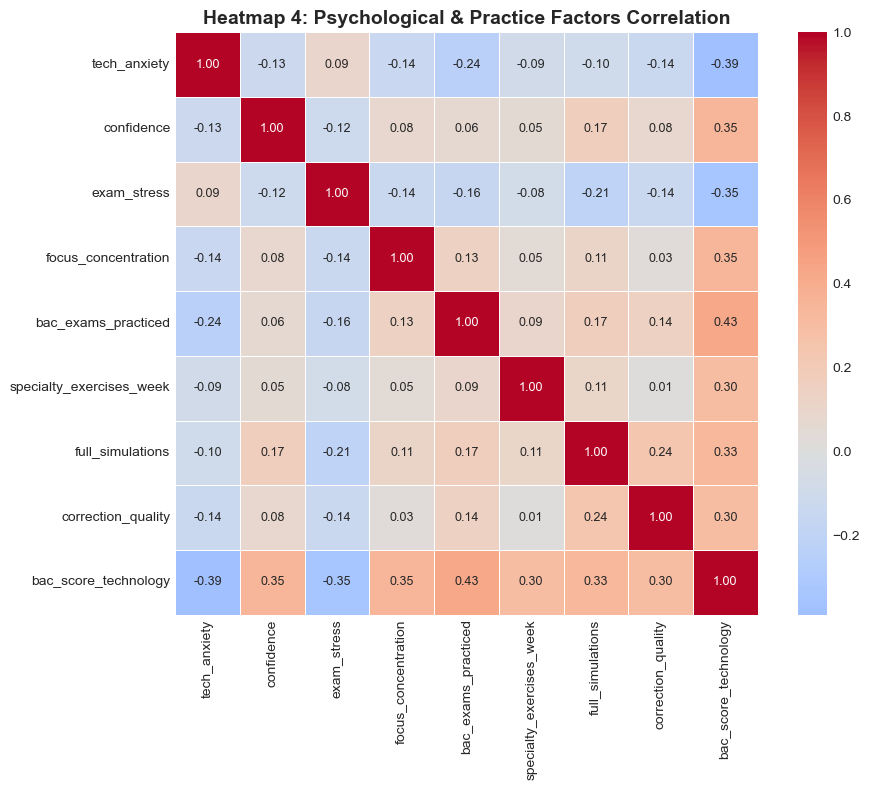


📋 Psychological & Practice factors correlation with BAC Score:
   • tech_anxiety: correlation = -0.390
   • confidence: correlation = 0.347
   • exam_stress: correlation = -0.347
   • focus_concentration: correlation = 0.352
   • bac_exams_practiced: correlation = 0.428
   • specialty_exercises_week: correlation = 0.300
   • full_simulations: correlation = 0.335
   • correction_quality: correlation = 0.304

📊 HEATMAP 5: Specialty Blocks Correlation


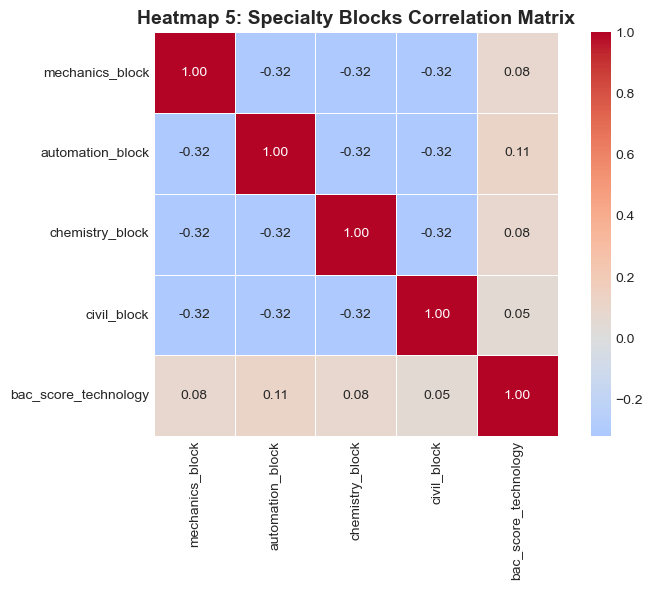


📋 Specialty blocks correlation with BAC Score:
   • mechanics_block: correlation = 0.080
   • automation_block: correlation = 0.109
   • chemistry_block: correlation = 0.085
   • civil_block: correlation = 0.053

✅ Correlation Analysis Complete


In [9]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation (exclude 'specialty' string column)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Get correlation with bac_score_technology (target)
bac_corr = corr_matrix['bac_score_technology'].sort_values(ascending=False)
print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 55)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:35s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: All Features Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top Features (highest correlation with BAC)
# ============================================
print("\n📊 HEATMAP 2: Top 15 Features Correlated with BAC Score")
print("=" * 55)

# Get top 15 features (excluding bac_score_technology itself)
top_features = bac_corr.head(16).index.tolist()  # includes bac_score_technology
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 Features Correlated with Technology BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Cross-Specialty Skills Correlation
# ============================================
print("\n📊 HEATMAP 3: Cross-Specialty Skills Correlation")
print("=" * 55)

cross_skills = ['problem_solving', 'diagram_interpretation', 'calculation_accuracy', 
                'technical_drawing', 'bac_score_technology']
available_cross = [c for c in cross_skills if c in df.columns]

if len(available_cross) > 1:
    corr_cross = df[available_cross].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_cross, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 3: Cross-Specialty Skills Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Cross-specialty skills correlation with BAC Score:")
    for skill in available_cross:
        if skill != 'bac_score_technology':
            print(f"   • {skill}: correlation = {corr_cross[skill]['bac_score_technology']:.3f}")

# ============================================
# HEATMAP 4: Psychological & Practice Factors Correlation
# ============================================
print("\n📊 HEATMAP 4: Psychological & Practice Factors Correlation")
print("=" * 55)

psycho_practice = ['tech_anxiety', 'confidence', 'exam_stress', 'focus_concentration',
                   'bac_exams_practiced', 'specialty_exercises_week', 'full_simulations', 
                   'correction_quality', 'bac_score_technology']
available_psycho = [p for p in psycho_practice if p in df.columns]

if len(available_psycho) > 1:
    corr_psycho = df[available_psycho].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_psycho, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 9})
    plt.title('Heatmap 4: Psychological & Practice Factors Correlation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Psychological & Practice factors correlation with BAC Score:")
    for factor in available_psycho:
        if factor != 'bac_score_technology':
            print(f"   • {factor}: correlation = {corr_psycho[factor]['bac_score_technology']:.3f}")

# ============================================
# HEATMAP 5: Specialty Blocks Correlation
# ============================================
print("\n📊 HEATMAP 5: Specialty Blocks Correlation")
print("=" * 55)

blocks = ['mechanics_block', 'automation_block', 'chemistry_block', 'civil_block', 'bac_score_technology']
available_blocks = [b for b in blocks if b in df.columns]

if len(available_blocks) > 1:
    corr_blocks = df[available_blocks].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_blocks, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 5: Specialty Blocks Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Specialty blocks correlation with BAC Score:")
    for block in available_blocks:
        if block != 'bac_score_technology':
            print(f"   • {block}: correlation = {corr_blocks[block]['bac_score_technology']:.3f}")

print("\n" + "=" * 55)
print("✅ Correlation Analysis Complete")
print("=" * 55)

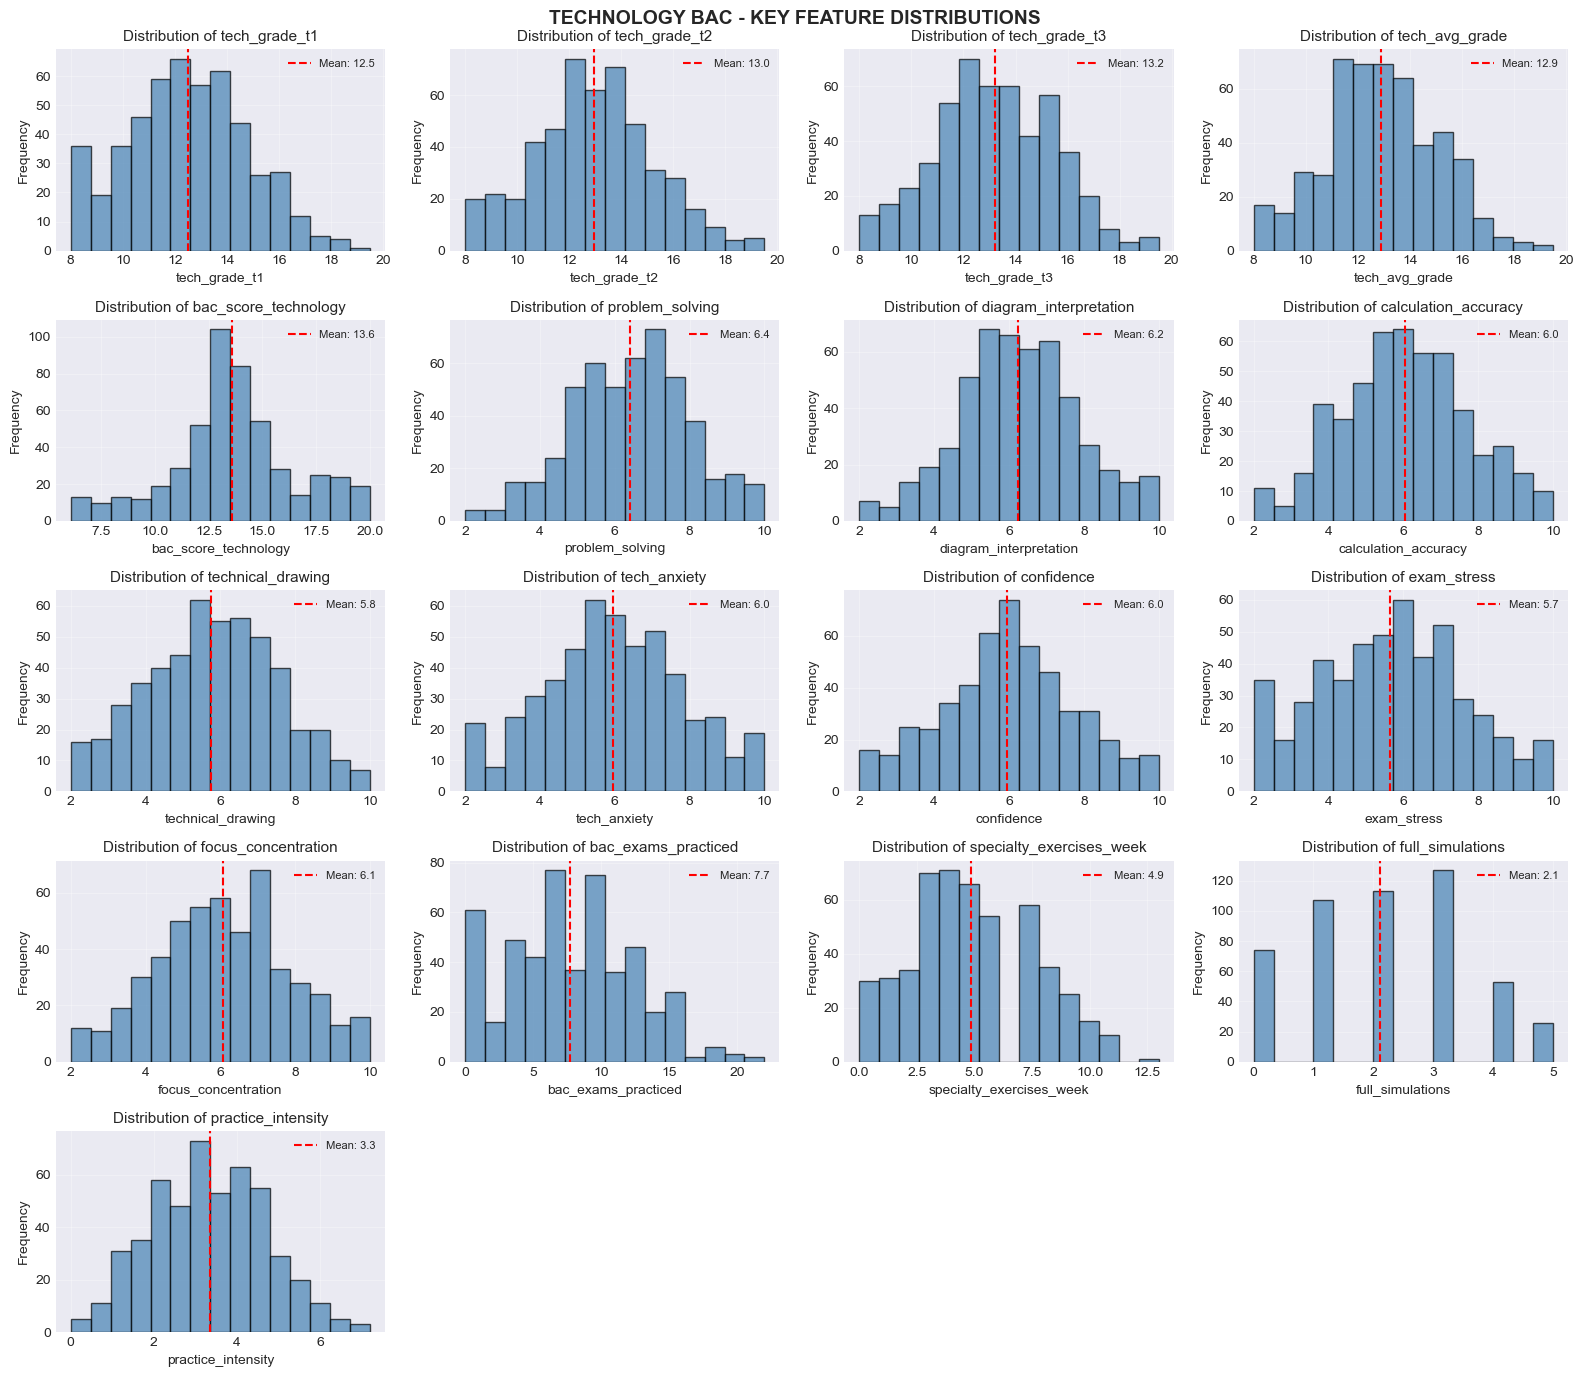


📊 KEY FEATURES SUMMARY STATISTICS
       tech_grade_t1  tech_grade_t2  tech_grade_t3  tech_avg_grade  \
count          500.0          500.0          500.0           500.0   
mean            12.5           13.0           13.2            12.9   
std              2.3            2.3            2.3             2.2   
min              8.0            8.0            8.0             8.0   
25%             10.9           11.5           11.7            11.6   
50%             12.5           13.0           13.2            12.8   
75%             14.0           14.4           14.9            14.3   
max             19.5           19.5           19.5            19.5   

       bac_score_technology  problem_solving  diagram_interpretation  \
count                 500.0            500.0                   500.0   
mean                   13.6              6.4                     6.2   
std                     2.9              1.6                     1.6   
min                     6.1              2.0  

In [10]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS 
# ============================================

import matplotlib.pyplot as plt

# Select key features to visualize (Technology specific)
key_features = [
    'tech_grade_t1', 'tech_grade_t2', 'tech_grade_t3', 'tech_avg_grade', 'bac_score_technology',
    'problem_solving', 'diagram_interpretation', 'calculation_accuracy', 'technical_drawing',
    'tech_anxiety', 'confidence', 'exam_stress', 'focus_concentration',
    'bac_exams_practiced', 'specialty_exercises_week', 'full_simulations', 'practice_intensity'
]

# Filter only features that exist in dataframe
available_features = [f for f in key_features if f in df.columns]

# Calculate grid size
n_features = len(available_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('TECHNOLOGY BAC - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics for key features
print("\n" + "=" * 60)
print("📊 KEY FEATURES SUMMARY STATISTICS")
print("=" * 60)

summary_stats = df[available_features].describe().round(1)
print(summary_stats)

# Additional technology-specific stats by specialty
print("\n" + "=" * 60)
print("📊 TECHNOLOGY SKILLS BREAKDOWN BY SPECIALTY")
print("=" * 60)

specialties = df['specialty'].unique()

for specialty in specialties:
    df_spec = df[df['specialty'] == specialty]
    print(f"\n🔧 {specialty}:")
    
    if specialty == 'GM':
        skills = ['mechanics_rdm', 'material_resistance', 'gear_transmission']
        for s in skills:
            if s in df_spec.columns:
                print(f"   {s}: mean={df_spec[s].mean():.1f}, corr={df_spec['bac_score_technology'].corr(df_spec[s]):.3f}")
                
    elif specialty == 'GE':
        skills = ['automation_grafcet', 'logic_circuits', 'electrical_systems']
        for s in skills:
            if s in df_spec.columns:
                print(f"   {s}: mean={df_spec[s].mean():.1f}, corr={df_spec['bac_score_technology'].corr(df_spec[s]):.3f}")
                
    elif specialty == 'GC':
        skills = ['structural_analysis', 'reinforced_concrete', 'road_construction']
        for s in skills:
            if s in df_spec.columns:
                print(f"   {s}: mean={df_spec[s].mean():.1f}, corr={df_spec['bac_score_technology'].corr(df_spec[s]):.3f}")
                
    elif specialty == 'GP':
        skills = ['organic_chemistry', 'polymer_chemistry', 'thermodynamics']
        for s in skills:
            if s in df_spec.columns:
                print(f"   {s}: mean={df_spec[s].mean():.1f}, corr={df_spec['bac_score_technology'].corr(df_spec[s]):.3f}")

# Cross-specialty skills by specialty
print("\n" + "=" * 60)
print("📊 CROSS-SPECIALTY SKILLS BY SPECIALTY")
print("=" * 60)

cross_skills = ['problem_solving', 'diagram_interpretation', 'calculation_accuracy', 'technical_drawing']

for specialty in specialties:
    df_spec = df[df['specialty'] == specialty]
    print(f"\n🔧 {specialty}:")
    for skill in cross_skills:
        if skill in df_spec.columns:
            print(f"   {skill}: mean={df_spec[skill].mean():.1f}, corr={df_spec['bac_score_technology'].corr(df_spec[skill]):.3f}")

print("\n" + "=" * 60)
print("✅ Cell 8 complete!")
print("=" * 60)

In [11]:
# ============================================
# CELL 9: FEATURE ENGINEERING - TECHNOLOGY
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy of the dataframe for feature engineering
df_fe = df.copy()

# ============================================
# 1. Specialty Blocks (Already exist, ensure they're rounded)
# ============================================
df_fe['mechanics_block'] = df_fe['mechanics_block'].round(1)
df_fe['automation_block'] = df_fe['automation_block'].round(1)
df_fe['chemistry_block'] = df_fe['chemistry_block'].round(1)
df_fe['civil_block'] = df_fe['civil_block'].round(1)

# ============================================
# 2. Problem Solving Composite (Already have, ensure rounded)
# ============================================
# problem_solving and diagram_interpretation already exist
df_fe['problem_solving_composite'] = (df_fe['problem_solving'] + df_fe['diagram_interpretation']) / 2
df_fe['problem_solving_composite'] = np.round(df_fe['problem_solving_composite'], 1)

# ============================================
# 3. Practice Intensity (Already have, ensure rounded)
# ============================================
df_fe['practice_intensity'] = df_fe['practice_intensity'].round(1)

# ============================================
# 4. Psychological Health (inverse of anxiety + confidence)
# ============================================
df_fe['psychological_health'] = (df_fe['confidence'] + df_fe['focus_concentration'] + (10 - df_fe['tech_anxiety']) + (10 - df_fe['exam_stress'])) / 4
df_fe['psychological_health'] = np.round(df_fe['psychological_health'], 1)

# ============================================
# 5. Study Quality (based on consistency and study hours)
# ============================================
df_fe['study_quality'] = (df_fe['consistency'] * 0.5 + df_fe['study_hours'] / 12 * 10 * 0.3 + df_fe['correction_quality'] * 0.2)
df_fe['study_quality'] = np.round(df_fe['study_quality'], 1)

# ============================================
# 6. Imbalance Score (variance between non-zero specialty blocks)
# ============================================
# This is already calculated in Cell 2, keep as is
df_fe['imbalance_score'] = df_fe['imbalance_score'].round(2)

# ============================================
# 7. Exam Preparation Score
# ============================================
df_fe['exam_prep_score'] = (df_fe['bac_exams_practiced'] / 30 * 10)
df_fe['exam_prep_score'] = np.round(df_fe['exam_prep_score'], 1)

# ============================================
# 8. Overall Skill Score (average of all relevant specialty skills)
# ============================================
# Initialize with zeros
df_fe['overall_skill_score'] = 0

# For each specialty, calculate average of its specific skills
gm_mask = df_fe['specialty'] == 'GM'
ge_mask = df_fe['specialty'] == 'GE'
gc_mask = df_fe['specialty'] == 'GC'
gp_mask = df_fe['specialty'] == 'GP'

if gm_mask.any():
    df_fe.loc[gm_mask, 'overall_skill_score'] = (
        df_fe.loc[gm_mask, 'mechanics_rdm'] + 
        df_fe.loc[gm_mask, 'material_resistance'] + 
        df_fe.loc[gm_mask, 'gear_transmission']
    ) / 3

if ge_mask.any():
    df_fe.loc[ge_mask, 'overall_skill_score'] = (
        df_fe.loc[ge_mask, 'automation_grafcet'] + 
        df_fe.loc[ge_mask, 'logic_circuits'] + 
        df_fe.loc[ge_mask, 'electrical_systems']
    ) / 3

if gc_mask.any():
    df_fe.loc[gc_mask, 'overall_skill_score'] = (
        df_fe.loc[gc_mask, 'structural_analysis'] + 
        df_fe.loc[gc_mask, 'reinforced_concrete'] + 
        df_fe.loc[gc_mask, 'road_construction']
    ) / 3

if gp_mask.any():
    df_fe.loc[gp_mask, 'overall_skill_score'] = (
        df_fe.loc[gp_mask, 'organic_chemistry'] + 
        df_fe.loc[gp_mask, 'polymer_chemistry'] + 
        df_fe.loc[gp_mask, 'thermodynamics']
    ) / 3

df_fe['overall_skill_score'] = np.round(df_fe['overall_skill_score'], 1)

# ============================================
# Display new features
# ============================================
print("\n✅ New features created:")
print("   • problem_solving_composite (problem_solving + diagram_interpretation)/2")
print("   • psychological_health (confidence + focus - anxiety - stress)")
print("   • study_quality (consistency + study_hours + correction_quality)")
print("   • exam_prep_score (bac_exams_practiced normalized to 0-10)")
print("   • overall_skill_score (average of specialty-specific skills)")

print("\n📊 First 5 rows (selected columns):")
selected_cols = ['bac_score_technology', 'specialty', 'problem_solving_composite', 
                 'psychological_health', 'study_quality', 'exam_prep_score', 'overall_skill_score']
available_selected = [c for c in selected_cols if c in df_fe.columns]
print(df_fe[available_selected].head().to_string())

print("\n📊 New features statistics:")
print(df_fe[available_selected].describe().to_string())

# Store the enhanced dataframe
df = df_fe.copy()

print("\n✅ Feature engineering complete. Total columns:", df.shape[1])
print("=" * 40)

FEATURE ENGINEERING

✅ New features created:
   • problem_solving_composite (problem_solving + diagram_interpretation)/2
   • psychological_health (confidence + focus - anxiety - stress)
   • study_quality (consistency + study_hours + correction_quality)
   • exam_prep_score (bac_exams_practiced normalized to 0-10)
   • overall_skill_score (average of specialty-specific skills)

📊 First 5 rows (selected columns):
   bac_score_technology specialty  problem_solving_composite  psychological_health  study_quality  exam_prep_score  overall_skill_score
0                  14.0        GM                        6.6                   3.9            3.5              1.0                  6.6
1                  17.6        GM                        8.6                   6.1            6.3              6.7                  7.9
2                  19.4        GM                        6.4                   7.0            6.2              4.3                  7.9
3                  15.0        GM      

In [12]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT (with encoding)
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# ============================================
# Encode categorical variables
# ============================================

# Make a copy to avoid modifying original
df_encoded = df.copy()

# Encode 'specialty' column
le = LabelEncoder()
df_encoded['specialty_encoded'] = le.fit_transform(df_encoded['specialty'])
df_encoded = df_encoded.drop('specialty', axis=1)

print("✅ Encoded 'specialty' column to numeric:")
for i, category in enumerate(le.classes_):
    print(f"   {category} → {i}")

# ============================================
# Define features (X) and target (y)
# ============================================

exclude_cols = ['bac_score_technology']
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['bac_score_technology']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score_technology")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df_encoded)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df_encoded)*100:.0f}%)")

# ============================================
# Display first few rows
# ============================================
print("\n📋 First 3 rows of training features:")
print(X_train.head(3).to_string())

print("\n📋 First 3 target values (bac_score_technology):")
print(y_train.head(3).tolist())

# ============================================
# Verify no data leakage
# ============================================
print("\n✅ No overlap between train and test:")
print(f"   Train indices: {X_train.index[:5].tolist()}...")
print(f"   Test indices:  {X_test.index[:5].tolist()}...")

# Update df for later cells
df = df_encoded.copy()
print("\n✅ Data ready for model training (Cell 11)")

TRAIN/TEST SPLIT
✅ Encoded 'specialty' column to numeric:
   GC → 0
   GE → 1
   GM → 2
   GP → 3

📊 Features (X): 47 columns
📊 Target (y): bac_score_technology

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

📋 First 3 rows of training features:
     tech_grade_t1  tech_grade_t2  tech_grade_t3  tech_avg_grade  tech_trend  mechanics_rdm  material_resistance  gear_transmission  automation_grafcet  logic_circuits  electrical_systems  structural_analysis  reinforced_concrete  road_construction  organic_chemistry  polymer_chemistry  thermodynamics  problem_solving  diagram_interpretation  calculation_accuracy  technical_drawing  bac_exams_practiced  specialty_exercises_week  full_simulations  correction_quality  tech_anxiety  confidence  exam_stress  focus_concentration  study_hours  consistency  teacher_quality  lab_access  tutoring  mechanics_block  automation_block  chemistry_block  civil_block  imbalance_score  practice_intensity  psychologica

In [13]:
# ============================================
# CELL 11: MODEL TRAINING - TECHNOLOGY BAC
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING - TECHNOLOGY BAC")
print("=" * 40)

# ============================================
# Train Random Forest Regressor
# ============================================

print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# ============================================
# Make predictions
# ============================================
y_pred = model.predict(X_test)

# ============================================
# Evaluate model
# ============================================
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# ============================================
# Feature Importance
# ============================================
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 most important features:")
for i, row in feature_importance_df.head(20).iterrows():
    print(f"   {row['feature']:35s}: {row['importance']:.4f}")

# ============================================
# Sample predictions vs actual
# ============================================
print("\n" + "=" * 40)
print("SAMPLE PREDICTIONS (First 10 test students)")
print("=" * 40)

sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred[:10], 1),
    'Error': np.round(y_test.values[:10] - y_pred[:10], 1)
})
print(sample_df.to_string())

print("\n✅ Model ready for Cell 12")

MODEL TRAINING - TECHNOLOGY BAC

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  0.93 points
   RMSE: 1.17 points
   R²:   0.863

FEATURE IMPORTANCE

Top 20 most important features:
   overall_skill_score                : 0.4428
   problem_solving_composite          : 0.1157
   tech_avg_grade                     : 0.1051
   tech_grade_t3                      : 0.0623
   practice_intensity                 : 0.0258
   psychological_health               : 0.0194
   diagram_interpretation             : 0.0193
   tech_grade_t1                      : 0.0192
   problem_solving                    : 0.0146
   technical_drawing                  : 0.0145
   psychological_composite            : 0.0136
   correction_quality                 : 0.0127
   tech_grade_t2                      : 0.0104
   study_quality                      : 0.0098
   focus_concentration                : 0.0094
   teacher_quality                    : 0.0090

MODEL EVALUATION (DETAILED) - TECHNOLOGY BAC

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     0.928 points
   Mean Squared Error (MSE):      1.376
   Root Mean Squared Error (RMSE): 1.173 points
   R² Score:                      0.863

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 0.980 (98.0%)

   Confusion Matrix:
   True Negatives (correct fail):  9
   False Positives:                2
   False Negatives:                0
   True Positives (correct pass):  89

   Classification Report:
              precision    recall  f1-score   support

  Fail (<10)       1.00      0.82      0.90        11
  Pass (≥10)       0.98      1.00      0.99        89

    accuracy                           0.98       100
   macro avg       0.99      0.91      0.94       100
weighted avg       0.98      0.98      0.98       100

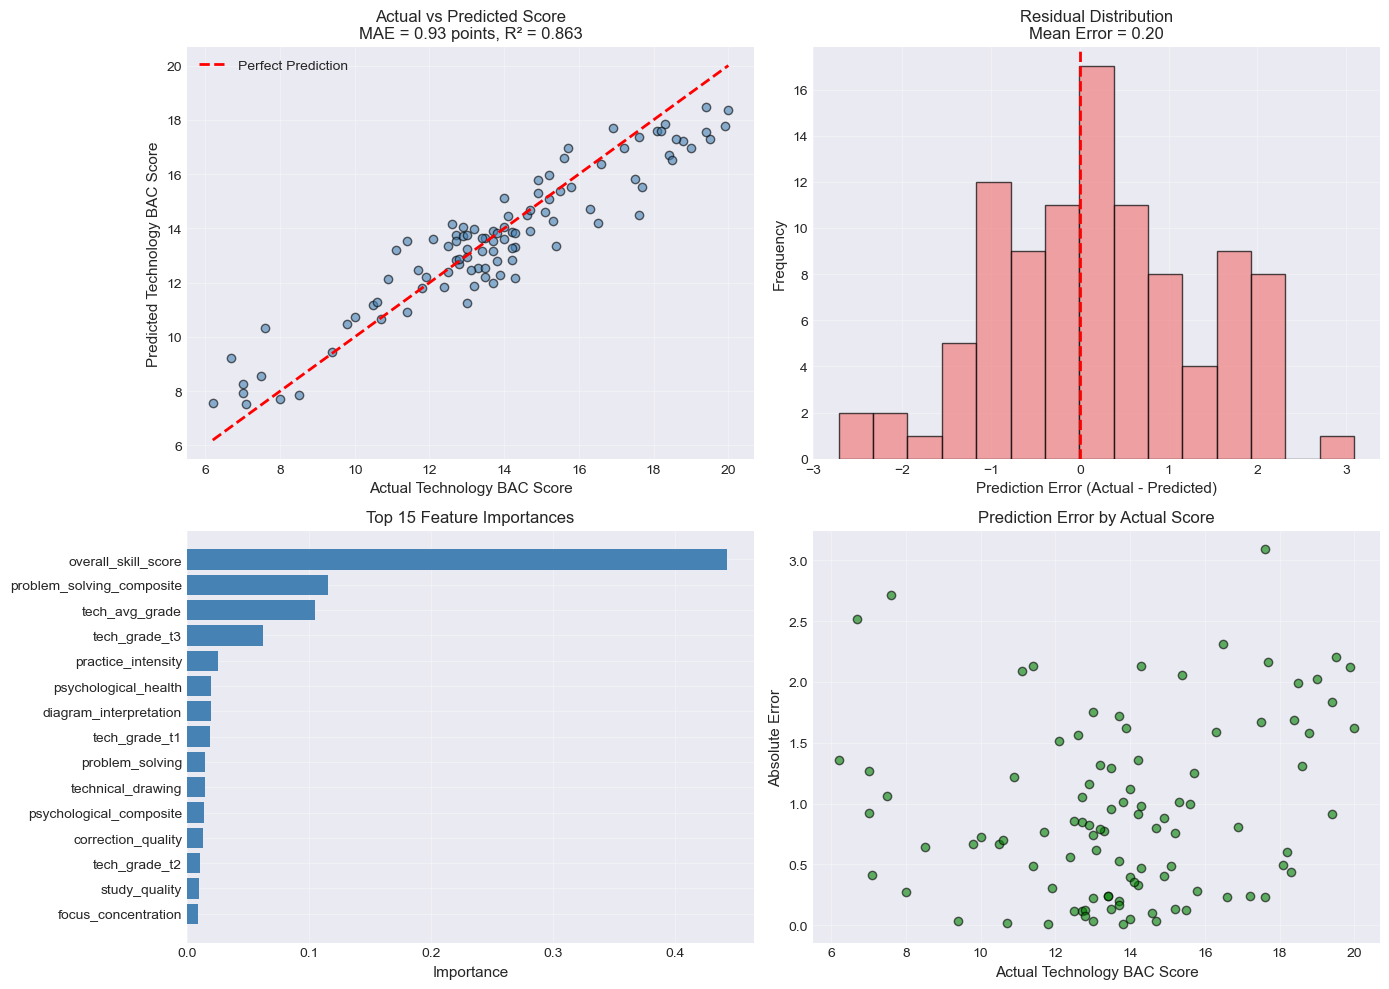


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      0.928 points
   Median Error:    0.793 points
   Max Error:       3.089 points
   Error < 1 point: 62.0% of predictions
   Error < 2 points: 88.0% of predictions

✅ Evaluation Complete


In [14]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED) - TECHNOLOGY BAC
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED) - TECHNOLOGY BAC")
print("=" * 50)

# ============================================
# 1. Score Prediction Metrics
# ============================================
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Success Classification (Pass/Fail)
# ============================================
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

print("\n   Classification Report:")
print(classification_report(y_true_class, y_pred_class, target_names=['Fail (<10)', 'Pass (≥10)']))

# ============================================
# 3. Visualizations
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted Score
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0,0].set_xlabel('Actual Technology BAC Score', fontsize=11)
axes[0,0].set_ylabel('Predicted Technology BAC Score', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted Score\nMAE = {mae:.2f} points, R² = {r2:.3f}', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
axes[0,1].set_ylabel('Frequency', fontsize=11)
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 15)
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(15)

axes[1,0].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance', fontsize=11)
axes[1,0].set_title('Top 15 Feature Importances', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Prediction Error by Actual Score
axes[1,1].scatter(y_test, np.abs(residuals), alpha=0.6, color='green', edgecolors='black')
axes[1,1].set_xlabel('Actual Technology BAC Score', fontsize=11)
axes[1,1].set_ylabel('Absolute Error', fontsize=11)
axes[1,1].set_title('Prediction Error by Actual Score', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 4. Error Summary
# ============================================
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Max Error:       {errors.max():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - TECHNOLOGY BAC

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 47)


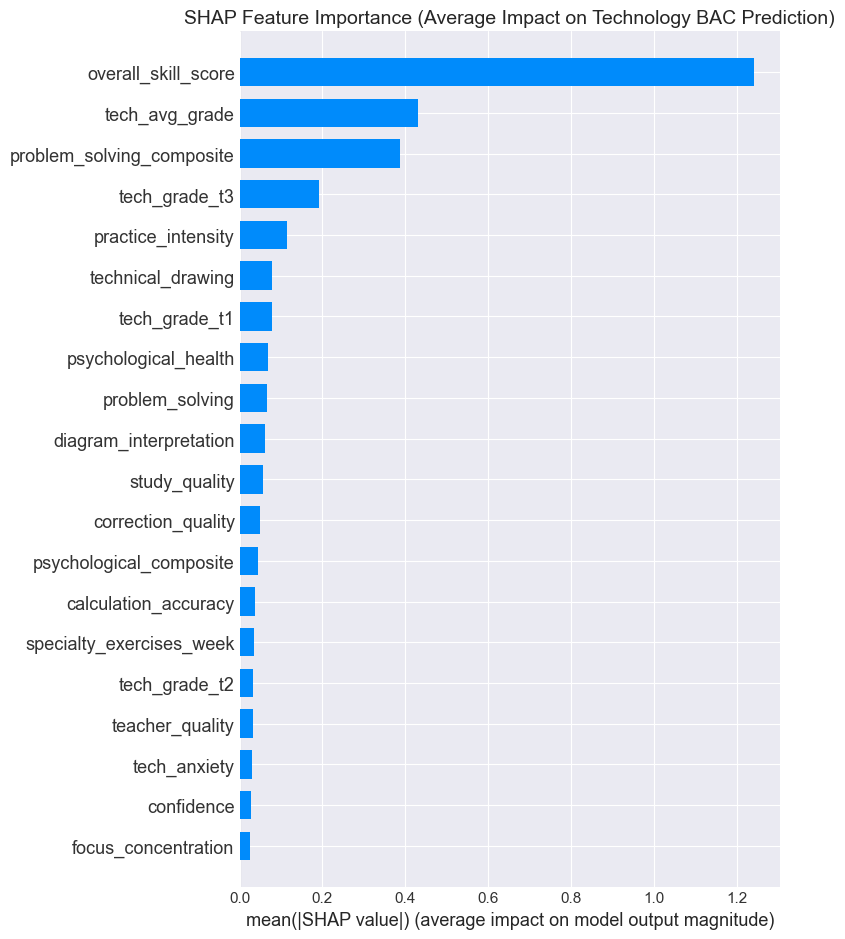

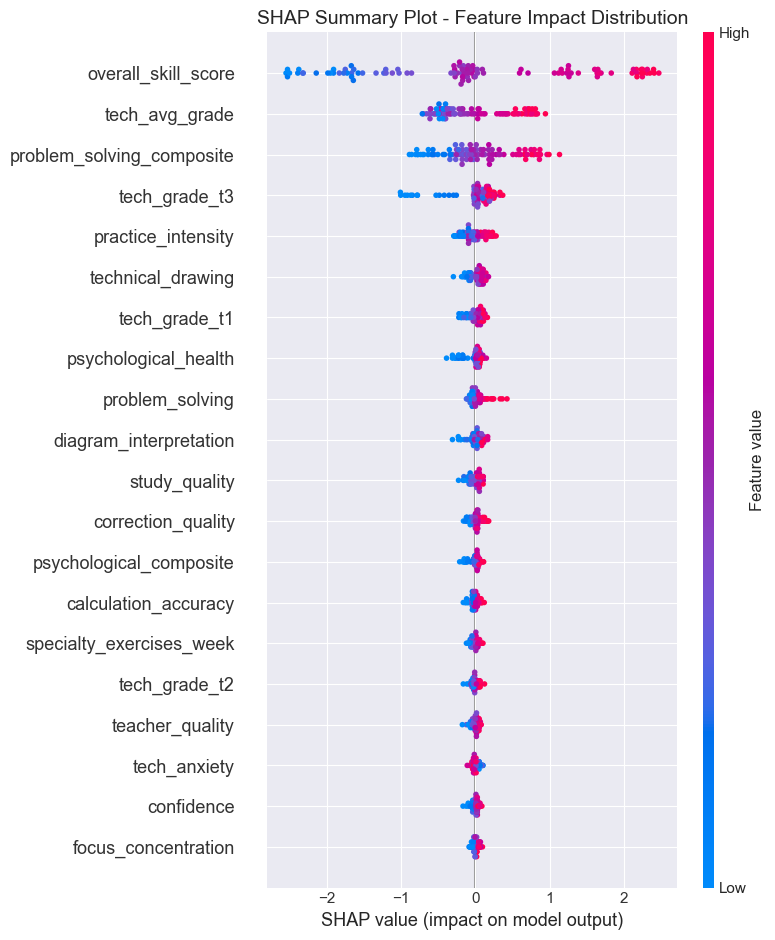


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual Technology BAC score: 14.3
   Predicted Technology BAC score: 12.2


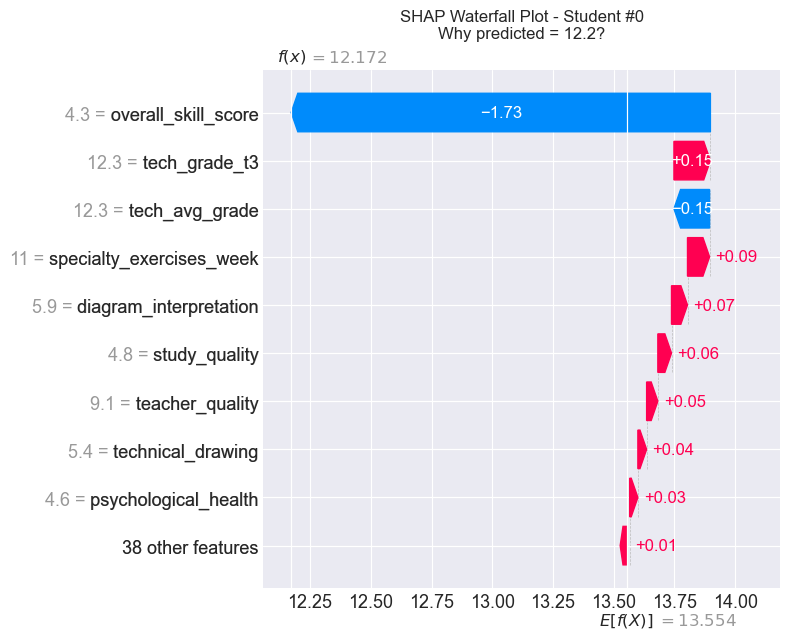


SIMPLE EXPLANATION (Student-Friendly)

✅ This student's predicted score: 12.2

🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):
   • overall_skill_score: -1.73 points
   • tech_avg_grade: -0.15 points
   • study_hours: -0.03 points
   • tech_grade_t1: -0.02 points
   • reinforced_concrete: -0.02 points

🟢 FACTORS THAT RAISED THE SCORE (Strengths):
   • tech_grade_t3: +0.15 points
   • specialty_exercises_week: +0.09 points
   • diagram_interpretation: +0.07 points
   • study_quality: +0.06 points
   • teacher_quality: +0.05 points

✅ SHAP Explainability Complete


In [15]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - TECHNOLOGY BAC
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - TECHNOLOGY BAC")
print("=" * 50)

# ============================================
# Create SHAP explainer
# ============================================
print("\n📊 Creating SHAP explainer...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# ============================================
# Visualization 1: Feature Importance (SHAP)
# ============================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Average Impact on Technology BAC Prediction)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Single Student Explanation
# ============================================
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

# Pick the first student from test set
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual Technology BAC score: {student_actual:.1f}")
print(f"   Predicted Technology BAC score: {student_pred:.1f}")

# Create waterfall plot for this student
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Print SHAP explanation in simple terms
# ============================================
print("\n" + "=" * 50)
print("SIMPLE EXPLANATION (Student-Friendly)")
print("=" * 50)

# Get SHAP values for this student
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Create DataFrame with feature contributions
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': student_shap
})
shap_df['absolute'] = np.abs(shap_df['shap_value'])
shap_df = shap_df.sort_values('absolute', ascending=False)

# Separate positive and negative contributions
positive = shap_df[shap_df['shap_value'] > 0].head(5)
negative = shap_df[shap_df['shap_value'] < 0].head(5)

print(f"\n✅ This student's predicted score: {student_pred:.1f}")
print(f"\n🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['feature']}: -{abs(row['shap_value']):.2f} points")
else:
    print("   • None - this student has no major weaknesses!")

print(f"\n🟢 FACTORS THAT RAISED THE SCORE (Strengths):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['feature']}: +{row['shap_value']:.2f} points")
else:
    print("   • None")

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [16]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS (PER STUDENT) - TECHNOLOGY BAC
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - TECHNOLOGY BAC")
print("=" * 50)

# ============================================
# Use SHAP values to identify weaknesses
# ============================================

# Get feature names and SHAP values from Cell 13
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values for all test students
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# For each student, identify top 3 weaknesses and top 3 strengths
# ============================================

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Get negative contributions (weaknesses)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Get positive contributions (strengths)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Display first 10 students
# ============================================
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Strengths:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Most common weaknesses across all students
# ============================================
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 15 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(15):
    print(f"   • {feature}: {count} students")

# ============================================
# Generate actionable recommendations for Technology
# ============================================
print("\n" + "=" * 50)
print("ACTIONABLE RECOMMENDATIONS - TECHNOLOGY BAC")
print("=" * 50)

# Map features to Technology-specific recommendations
recommendation_map = {
    # Academic
    'tech_avg_grade': '📊 رفع المعدل العام في الفصول الثلاثة',
    'tech_grade_t1': '📊 تحسين الأداء في الفصل الأول',
    'tech_grade_t2': '📊 تحسين الأداء في الفصل الثاني',
    'tech_grade_t3': '📊 تحسين الأداء في الفصل الثالث',
    'tech_trend': '📈 الحفاظ على تحسن مستمر في المعدلات',
    
    # GM - Génie Mécanique
    'mechanics_rdm': '🔧 الميكانيك (RDM): ركز على دراسة الجهد القاطع وعزم الانحناء',
    'material_resistance': '🔩 مقاومة المواد: تدرب على حساب الإجهادات والتحريضات البسيطة',
    'gear_transmission': '⚙️ نقل الحركة: راجع حسابات نسب النقل والتروس',
    
    # GE - Génie Électrique
    'automation_grafcet': '⚡ الأتمتة (GRAFCET): تدرب على رسم وتفسير مخططات GRAFCET',
    'logic_circuits': '🔌 الدوائر المنطقية: راجع البوابات المنطقية والعدادات (7490)',
    'electrical_systems': '💡 الأنظمة الكهربائية: راجع المحركات والمقوّمات',
    
    # GC - Génie Civil
    'structural_analysis': '🏗️ التحليل الإنشائي: تدرب على حساب ردود الأفعال والجهود الداخلية',
    'reinforced_concrete': '🏢 الخرسانة المسلحة: راجع حسابات التسليح وقواعد BAEL',
    'road_construction': '🛣️ الطرق: راجع مكونات الطريق والمظهر الطولي والعرضي',
    
    # GP - Génie des Procédés
    'organic_chemistry': '🧪 الكيمياء العضوية: راجع التفاعلات العضوية والمجموعات الوظيفية',
    'polymer_chemistry': '🔬 كيمياء البوليمرات: تدرب على البلمرة والتصبن',
    'thermodynamics': '🔥 الثيرموديناميك: راجع حساب كميات الحرارة والمسعر الحراري',
    
    # Cross-specialty skills
    'problem_solving': '🔍 حل المسائل الهندسية: قسم المسألة إلى خطوات صغيرة',
    'diagram_interpretation': '📐 قراءة المخططات: تدرب على تفسير المخططات التقنية',
    'calculation_accuracy': '🧮 دقة الحسابات: تأكد من وحدات القياس والحسابات',
    'technical_drawing': '✏️ الرسم التقني: تدرب على قراءة وإكمال الرسومات التقنية',
    
    # Practice
    'bac_exams_practiced': '📝 الامتحانات السابقة: حل امتحان بكالوريا تقني كل أسبوع',
    'specialty_exercises_week': '✍️ تمارين التخصص: حل تمارين في تخصصك أسبوعياً',
    'full_simulations': '⏱️ محاكاة كاملة: حل امتحان كامل بوقته الحقيقي',
    'correction_quality': '🔍 تصحيح الأخطاء: حلل أخطائك وافهم سببها',
    
    # Psychological
    'tech_anxiety': '😌 قلق التقني: ابدأ بتمارين سهلة وزد الصعوبة تدريجياً',
    'confidence': '💪 الثقة: حل تمارين متنوعة وزد ثقتك بقدراتك',
    'exam_stress': '😓 توتر الامتحان: تدرب على التنفس العميق وتنظيم الوقت',
    'focus_concentration': '🎯 التركيز: خذ فترات راحة قصيرة أثناء الدراسة',
    
    # Study Habits
    'study_hours': '⏰ ساعات الدراسة: خصص 4-6 ساعات أسبوعياً للمادة',
    'consistency': '📅 الانتظام: ذاكر يومياً بدلاً من المذاكرة المكثفة',
    'teacher_quality': '👨‍🏫 جودة الأستاذ: اطلب المساعدة عند الحاجة',
    'lab_access': '🔬 الأعمال المخبرية: استفد من حصص TP',
    
    # Derived
    'imbalance_score': '⚖️ عدم التوازن: وازن بين مهاراتك في جميع فروع التخصص',
    'practice_intensity': '⚡ كثافة التمارين: زد عدد التمارين التي تحلها',
    'psychological_health': '🧠 الصحة النفسية: ثقتك تؤثر بشكل كبير على أدائك',
    'study_quality': '📚 جودة الدراسة: ركز على الفهم وليس الحفظ',
    'exam_prep_score': '📝 التحضير للامتحان: حل امتحانات سابقة هو أفضل طريقة',
    'overall_skill_score': '🎯 المستوى العام: ركز على نقاط ضعفك في تخصصك'
}

# Get unique weaknesses and their recommendations
unique_weaknesses = set(all_weaknesses)
print("\n📋 Personalized Recommendations based on common weaknesses:")
for weakness in list(unique_weaknesses)[:15]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        print(f"   • {weakness}: (ركز على تحسين هذا المجال)")

# ============================================
# Technology-specific tips
# ============================================
print("\n" + "=" * 50)
print("💡 نصائح خاصة لمادة التكنولوجيا (التقني الرياضي)")
print("=" * 50)
print("   • المهارات الأساسية (problem-solving, diagram_interpretation) مهمة جداً")
print("   • حل امتحانات سابقة يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات")
print("   • قلق المادة يؤثر سلباً - حاول تقليله بتمارين التنفس")
print("   • ركز على تخصصك (GM/GE/GC/GP) أولاً ثم المهارات المشتركة")
print("   • قراءة المخططات التقنية (GRAFCET, dessin technique) أساسية")

# ============================================
# Save weakness analysis to CSV
# ============================================
weakness_df.to_csv('weakness_analysis_technology.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_technology.csv'")

print("\n" + "=" * 50)
print("✅ Weakness Analysis Complete")
print("=" * 50)

WEAKNESS ANALYSIS - TECHNOLOGY BAC

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=14.3, Predicted=12.2
   🔴 Weaknesses:
      • overall_skill_score (-1.73)
      • tech_avg_grade (-0.15)
      • study_hours (-0.03)
   🟢 Strengths:
      • tech_grade_t3 (+0.15)
      • specialty_exercises_week (+0.09)
      • diagram_interpretation (+0.07)

🔹 STUDENT 2: Actual=13.5, Predicted=12.2
   🔴 Weaknesses:
      • overall_skill_score (-1.77)
      • confidence (-0.17)
      • mechanics_rdm (-0.07)
   🟢 Strengths:
      • tech_grade_t3 (+0.15)
      • study_quality (+0.10)
      • technical_drawing (+0.08)

🔹 STUDENT 3: Actual=16.6, Predicted=16.4
   🔴 Weaknesses:
      • tech_avg_grade (-0.47)
      • practice_intensity (-0.09)
      • tech_grade_t1 (-0.07)
   🟢 Strengths:
      • overall_skill_score (+2.17)
      • problem_solving_composite (+0.79)
      • problem_solving (+0.14)

🔹 STUDENT 4: Actual=16.3, Predicted=14.7
   🔴 Weak

SIMULATION ENGINE - TECHNOLOGY BAC
How improving study habits affects your Technology BAC score
Based on correlations from our dataset

📊 Real correlations from your data:
   problem_solving → BAC: 0.524
   diagram_interpretation → BAC: 0.562
   calculation_accuracy → BAC: 0.396
   bac_exams_practiced → BAC: 0.428
   tech_anxiety → BAC: -0.390
   confidence → BAC: 0.347

👤 Selected student (average profile from GM):
   Current Technology BAC score: 13.6
   Problem Solving: 7.5/10
   Diagram Interpretation: 4.9/10
   Bac exams practiced: 6/30
   Tech Anxiety: 6.3/10
   Confidence: 4.2/10

📈 SIMULATION RESULTS (for GM specialty):
------------------------------------------------------------

🟢 🔍 تحسين حل المسائل +2 نقطة:
   13.6 → 15.2
   📈 التحسن: +1.57 نقطة

🟢 📐 تحسين قراءة المخططات +2 نقطة:
   13.6 → 15.3
   📈 التحسن: +1.69 نقطة

🟢 🧮 تحسين دقة الحسابات +2 نقطة:
   13.6 → 14.8
   📈 التحسن: +1.19 نقطة

🟢 🔧 تحسين مهارات التخصص +2 نقطة (GM):
   13.6 → 15.3
   📈 التحسن: +1.74 نقطة

⚪ 📝 حل 1

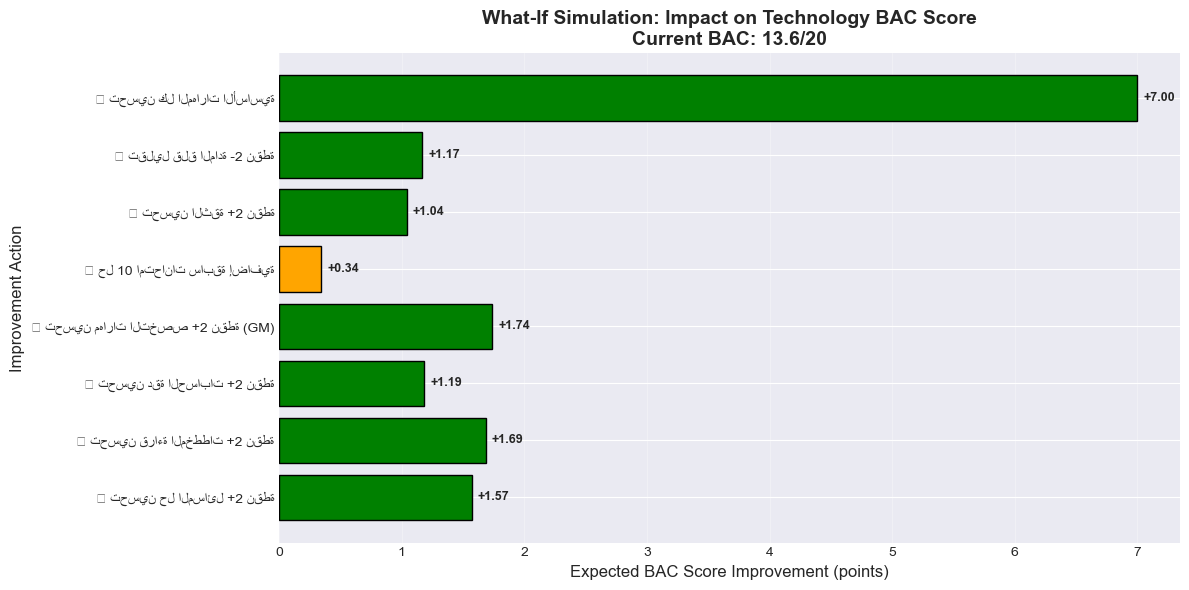


📊 جدول تأثير تحسين العادات الدراسية - التكنولوجيا


NameError: name 'base_scale_factors' is not defined

In [17]:
# ============================================
# CELL 15: SIMULATION ENGINE - TECHNOLOGY BAC
# Based on correlations from your data
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("SIMULATION ENGINE - TECHNOLOGY BAC")
print("How improving study habits affects your Technology BAC score")
print("Based on correlations from our dataset")
print("=" * 60)

# ============================================
# Step 1: Calculate average effects from correlations
# ============================================

# Get correlations with BAC score
bac_corr = df.corr()['bac_score_technology']

# Extract key correlations
problem_solving_corr = bac_corr.get('problem_solving', 0.52)
diagram_corr = bac_corr.get('diagram_interpretation', 0.56)
calculation_corr = bac_corr.get('calculation_accuracy', 0.40)
exam_corr = bac_corr.get('bac_exams_practiced', 0.43)
anxiety_corr = bac_corr.get('tech_anxiety', -0.39)
confidence_corr = bac_corr.get('confidence', 0.35)
practice_intensity_corr = bac_corr.get('practice_intensity', 0.53)

print(f"\n📊 Real correlations from your data:")
print(f"   problem_solving → BAC: {problem_solving_corr:.3f}")
print(f"   diagram_interpretation → BAC: {diagram_corr:.3f}")
print(f"   calculation_accuracy → BAC: {calculation_corr:.3f}")
print(f"   bac_exams_practiced → BAC: {exam_corr:.3f}")
print(f"   tech_anxiety → BAC: {anxiety_corr:.3f}")
print(f"   confidence → BAC: {confidence_corr:.3f}")

# ============================================
# Step 2: Find a representative student for each specialty
# ============================================

# Get a student from each specialty
avg_bac = df['bac_score_technology'].mean()
representative_students = {}

for specialty in df['specialty_encoded'].unique():
    # Get specialty name
    if specialty == 0:
        spec_name = 'GM'
    elif specialty == 1:
        spec_name = 'GE'
    elif specialty == 2:
        spec_name = 'GC'
    else:
        spec_name = 'GP'
    
    df_spec = df[df['specialty_encoded'] == specialty]
    student = df_spec.iloc[(df_spec['bac_score_technology'] - avg_bac).abs().argsort()[:1]].iloc[0]
    representative_students[spec_name] = student

# Use GM as default for simulation
target_student = representative_students['GM']
target_specialty = 'GM'

print(f"\n👤 Selected student (average profile from {target_specialty}):")
print(f"   Current Technology BAC score: {target_student['bac_score_technology']:.1f}")
print(f"   Problem Solving: {target_student.get('problem_solving', 5):.1f}/10")
print(f"   Diagram Interpretation: {target_student.get('diagram_interpretation', 5):.1f}/10")
print(f"   Bac exams practiced: {target_student.get('bac_exams_practiced', 5):.0f}/30")
print(f"   Tech Anxiety: {target_student.get('tech_anxiety', 5):.1f}/10")
print(f"   Confidence: {target_student.get('confidence', 5):.1f}/10")

# ============================================
# Step 3: Simulation function
# ============================================

def simulate_improvement(student, improvements, specialty='GM'):
    """
    Simulate BAC improvement based on correlation coefficients
    """
    # Scale factors: how many BAC points per unit of improvement
    base_scale_factors = {
        'problem_solving': problem_solving_corr * 1.5,
        'diagram_interpretation': diagram_corr * 1.5,
        'calculation_accuracy': calculation_corr * 1.5,
        'bac_exams_practiced': exam_corr * 0.8,      # points per +10 exams
        'tech_anxiety': -anxiety_corr * 1.5,         # reducing anxiety helps
        'confidence': confidence_corr * 1.5,
        'practice_intensity': practice_intensity_corr * 1.2
    }
    
    # Add specialty-specific skills
    if specialty == 'GM':
        base_scale_factors['mechanics_rdm'] = 0.58 * 1.5
        base_scale_factors['material_resistance'] = 0.61 * 1.5
        base_scale_factors['gear_transmission'] = 0.60 * 1.5
    elif specialty == 'GE':
        base_scale_factors['automation_grafcet'] = 0.63 * 1.5
        base_scale_factors['logic_circuits'] = 0.57 * 1.5
        base_scale_factors['electrical_systems'] = 0.48 * 1.5
    elif specialty == 'GC':
        base_scale_factors['structural_analysis'] = 0.61 * 1.5
        base_scale_factors['reinforced_concrete'] = 0.52 * 1.5
        base_scale_factors['road_construction'] = 0.43 * 1.5
    elif specialty == 'GP':
        base_scale_factors['organic_chemistry'] = 0.59 * 1.5
        base_scale_factors['polymer_chemistry'] = 0.53 * 1.5
        base_scale_factors['thermodynamics'] = 0.47 * 1.5
    
    original_score = student['bac_score_technology']
    gain = 0
    
    for feature, delta in improvements.items():
        if feature in base_scale_factors:
            if feature == 'bac_exams_practiced':
                gain += (delta / 10) * base_scale_factors[feature]
            elif feature == 'tech_anxiety':
                gain += (-delta) * base_scale_factors[feature]
            else:
                gain += delta * base_scale_factors[feature]
    
    new_score = min(original_score + gain, 20)
    new_score = max(new_score, 0)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Step 4: Test different scenarios
# ============================================

scenarios = [
    {"name": "🔍 تحسين حل المسائل +2 نقطة", "changes": {"problem_solving": 2}},
    {"name": "📐 تحسين قراءة المخططات +2 نقطة", "changes": {"diagram_interpretation": 2}},
    {"name": "🧮 تحسين دقة الحسابات +2 نقطة", "changes": {"calculation_accuracy": 2}},
    {"name": "🔧 تحسين مهارات التخصص +2 نقطة (GM)", "changes": {"mechanics_rdm": 2}},
    {"name": "📝 حل 10 امتحانات سابقة إضافية", "changes": {"bac_exams_practiced": 10}},
    {"name": "💪 تحسين الثقة +2 نقطة", "changes": {"confidence": 2}},
    {"name": "🧘 تقليل قلق المادة -2 نقطة", "changes": {"tech_anxiety": -2}},
    {"name": "✨ تحسين كل المهارات الأساسية", "changes": {
        "problem_solving": 2, "diagram_interpretation": 2, "calculation_accuracy": 2,
        "bac_exams_practiced": 10, "confidence": 2, "tech_anxiety": -2
    }}
]

print(f"\n📈 SIMULATION RESULTS (for {target_specialty} specialty):")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement(target_student, scenario["changes"], target_specialty)
    results.append(result)
    
    # Color code based on gain
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 التحسن: +{result['gain']:.2f} نقطة")

# ============================================
# Step 5: Best action recommendation
# ============================================

print("\n" + "=" * 60)
print("🎯 أفضل طريقة للتحسين - TECHNOLOGY")
print("=" * 60)

best_gain = max([r['gain'] for r in results[:-1]])  # Exclude combined
best_scenario = scenarios[[r['gain'] for r in results[:-1]].index(best_gain)]

print(f"\n✅ {best_scenario['name']}")
print(f"   → تحسن متوقع: +{best_gain:.2f} نقطة في البكالوريا")

# ============================================
# Step 6: Visualization
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

scenario_names = [s["name"][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected BAC Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on Technology BAC Score\nCurrent BAC: {target_student["bac_score_technology"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Step 7: Summary table
# ============================================

print("\n" + "=" * 60)
print("📊 جدول تأثير تحسين العادات الدراسية - التكنولوجيا")
print("=" * 60)

impact_table = pd.DataFrame({
    'العادة الدراسية': [
        'تحسين حل المسائل +2',
        'تحسين قراءة المخططات +2',
        'تحسين دقة الحسابات +2',
        'تحسين مهارات التخصص +2',
        'حل 10 امتحانات سابقة',
        'تحسين الثقة +2',
        'تقليل قلق المادة -2'
    ],
    'التحسن المتوقع': [
        f'+{base_scale_factors["problem_solving"]*2:.2f} نقطة',
        f'+{base_scale_factors["diagram_interpretation"]*2:.2f} نقطة',
        f'+{base_scale_factors["calculation_accuracy"]*2:.2f} نقطة',
        f'+{base_scale_factors["mechanics_rdm"]*2:.2f} نقطة (GM)',
        f'+{base_scale_factors["bac_exams_practiced"]:.2f} نقطة',
        f'+{base_scale_factors["confidence"]*2:.2f} نقطة',
        f'+{base_scale_factors["tech_anxiety"]*2:.2f} نقطة'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 نصيحة خاصة لمادة التكنولوجيا:")
print("   • حل المسائل وقراءة المخططات هما الأكثر تأثيراً")
print("   • حل امتحانات سابقة يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات")
print("   • قلق المادة يؤثر سلباً - حاول تقليله")
print("   • ركز على مهارات تخصصك أولاً ثم المهارات المشتركة")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [18]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - TECHNOLOGY BAC
# ============================================

import pandas as pd
import numpy as np

print("=" * 60)
print("📖 فهم نتائجك في مادة التكنولوجيا (التقني الرياضي)")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# ============================================
# Create a sample student profile (pick average student)
# ============================================

sample_student = df.iloc[50]
# Get the original specialty name (decode from encoded value)
specialty_map = {0: 'GM', 1: 'GE', 2: 'GC', 3: 'GP'}
student_specialty = specialty_map.get(int(sample_student['specialty_encoded']), 'GM')

print(f"\n👤 ملف الطالب:")
print(f"   التخصص: {student_specialty}")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score_technology']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['tech_avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# ============================================
# Explain specialty-specific skills
# ============================================

print("\n📚 مهاراتك الأساسية حسب تخصصك:")
print("-" * 60)

if student_specialty == 'GM':
    skills_to_explain = [
        ('mechanics_rdm', '🔧 الميكانيك (RDM): دراسة الجهد القاطع وعزم الانحناء',
         'ركز على حساب ردود الأفعال والجهود الداخلية في الروافد'),
        ('material_resistance', '🔩 مقاومة المواد: حساب الإجهادات والتحريضات',
         'تدرب على تطبيق شرط المقاومة واختيار المقاطع المناسبة'),
        ('gear_transmission', '⚙️ نقل الحركة: حسابات نسب النقل والتروس',
         'راجع العلاقات بين عدد الأسنان والسرعات')
    ]
elif student_specialty == 'GE':
    skills_to_explain = [
        ('automation_grafcet', '⚡ الأتمتة (GRAFCET): مخططات التحكم والمراحل',
         'تدرب على رسم وتفسير مخططات GRAFCET وحساب معادلات التنشيط'),
        ('logic_circuits', '🔌 الدوائر المنطقية: البوابات والعدادات',
         'راجع جداول الحقيقة والدوال المنطقية والعدادات (7490)'),
        ('electrical_systems', '💡 الأنظمة الكهربائية: المحركات والمقومات',
         'تدرب على حسابات القدرة والمزدوجة في المحركات')
    ]
elif student_specialty == 'GC':
    skills_to_explain = [
        ('structural_analysis', '🏗️ التحليل الإنشائي: حساب ردود الأفعال',
         'ركز على حساب الجهود الداخلية في الأنظمة المثلثية'),
        ('reinforced_concrete', '🏢 الخرسانة المسلحة: حسابات التسليح',
         'تدرب على تطبيق قواعد BAEL في الشد والانضغاط'),
        ('road_construction', '🛣️ الطرق: مكونات الطريق والمظهر الطولي',
         'راجع حسابات الميول والمسافات في الطرقات')
    ]
else:  # GP
    skills_to_explain = [
        ('organic_chemistry', '🧪 الكيمياء العضوية: التفاعلات والمجموعات الوظيفية',
         'راجع تفاعلات الأكسدة والهلجنة والأسترة'),
        ('polymer_chemistry', '🔬 كيمياء البوليمرات: البلمرة والتصبن',
         'تدرب على حساب قرينة التصبن وقرينة اليود'),
        ('thermodynamics', '🔥 الثيرموديناميك: حساب كميات الحرارة',
         'راجع استخدام المسعر الحراري وقوانين الديناميكا الحرارية')
    ]

for skill, name, advice in skills_to_explain:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
            level_advice = f"مستواك {value:.1f}/10 - ممتاز! حافظ عليه"
        elif value >= 5:
            level = "🟡 متوسط"
            level_advice = f"مستواك {value:.1f}/10 - يمكن تحسينه"
        else:
            level = "🔴 يحتاج إلى تحسين"
            level_advice = f"مستواك {value:.1f}/10 - ركز على هذه المهارة"
        
        print(f"\n{name}")
        print(f"   → {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain cross-specialty skills
# ============================================

print("\n" + "=" * 60)
print("🔍 المهارات المشتركة (جميع التخصصات)")
print("=" * 60)

cross_skills = [
    ('problem_solving', '🔍 حل المسائل الهندسية',
     'قسم المسألة إلى خطوات صغيرة وحلل المعطيات قبل البدء في الحل'),
    ('diagram_interpretation', '📐 قراءة وتحليل المخططات التقنية',
     'تدرب على قراءة مخططات GRAFCET والرسومات التقنية'),
    ('calculation_accuracy', '🧮 دقة الحسابات والوحدات',
     'تأكد دائماً من وحدات القياس ودقة العمليات الحسابية'),
    ('technical_drawing', '✏️ الرسم التقني وإكمال المخططات',
     'تدرب على إكمال الرسومات الناقصة وتمثيل الأبعاد')
]

for skill, name, advice in cross_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain psychological factors
# ============================================

print("\n" + "=" * 60)
print("🧠 العوامل النفسية وتأثيرها على أدائك")
print("=" * 60)

psycho_factors = [
    ('tech_anxiety', '😰 قلق مادة التكنولوجيا',
     'القلق يخفض نقطتك. ابدأ بتمارين سهلة وزد الصعوبة تدريجياً', True),
    ('confidence', '💪 الثقة بالنفس في المواد التقنية',
     'الثقة ترفع نقطتك. حل تمارين متنوعة وزد ثقتك بقدراتك', False),
    ('exam_stress', '😓 توتر الامتحان',
     'التوتر يؤثر سلباً. تدرب على التنفس العميق وتنظيم الوقت', True),
    ('focus_concentration', '🎯 التركيز أثناء حل المسائل',
     'التركيز يساعدك على حل المسائل بشكل أسرع وأدق', False)
]

for factor, name, advice, is_negative in psycho_factors:
    if factor in df.columns:
        value = sample_student[factor]
        if is_negative:
            if value <= 3:
                level = "🟢 ممتاز (منخفض)"
            elif value <= 6:
                level = "🟡 متوسط"
            else:
                level = "🔴 مرتفع (يؤثر سلباً)"
        else:
            if value >= 7:
                level = "🟢 ممتاز"
            elif value >= 5:
                level = "🟡 متوسط"
            else:
                level = "🔴 منخفض (يحتاج تحسين)"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain study habits
# ============================================

print("\n" + "=" * 60)
print("📖 عادات الدراسة وتأثيرها على نقطتك")
print("=" * 60)

study_habits = [
    ('bac_exams_practiced', '📚 عدد امتحانات البكالوريا التي حللتها', 30),
    ('specialty_exercises_week', '✍️ عدد تمارين التخصص التي تحلها أسبوعياً', 15),
    ('full_simulations', '⏱️ عدد الامتحانات الكاملة التي تحلها بوقت محدد', 5),
    ('study_hours', '⏰ عدد ساعات الدراسة الأسبوعية', 12),
    ('consistency', '📅 مدى انتظامك في الدراسة (من 1 إلى 10)', 10),
    ('correction_quality', '🔍 جودة تصحيحك لأخطائك وفهمها', 10)
]

for habit, name, max_val in study_habits:
    if habit in df.columns:
        value = sample_student[habit]
        percentage = (value / max_val) * 100
        
        if percentage >= 70:
            level = "🟢 ممتاز"
        elif percentage >= 50:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.0f}/{max_val}")
        print(f"   → مستواك: {level} ({percentage:.0f}%)")
        
        if habit == 'bac_exams_practiced' and value < 10:
            print(f"   💡 نصيحة: حاول حل {10 - value:.0f} امتحان إضافي")
        elif habit == 'specialty_exercises_week' and value < 8:
            print(f"   💡 نصيحة: ارفع عدد التمارين إلى 8-10 أسبوعياً")
        elif habit == 'full_simulations' and value < 2:
            print(f"   💡 نصيحة: حاول حل امتحان كامل بوقته الحقيقي كل أسبوع")
        elif habit == 'study_hours' and value < 4:
            print(f"   💡 نصيحة: زد ساعات الدراسة إلى 4-6 ساعات أسبوعياً")
        elif habit == 'consistency' and value < 6:
            print(f"   💡 نصيحة: حاول الدراسة يومياً بدلاً من المذاكرة المكثفة")
        elif habit == 'correction_quality' and value < 6:
            print(f"   💡 نصيحة: حلل أخطائك وافهم سببها قبل الانتقال إلى تمرين جديد")

# ============================================
# Derived features explanation
# ============================================

print("\n" + "=" * 60)
print("📊 مؤشرات مركبة (مشتقة من مهاراتك)")
print("=" * 60)

derived_features = [
    ('problem_solving_composite', '🔍 مستوى حل المسائل والتحليل',
     'متوسط مهاراتك في حل المسائل وقراءة المخططات'),
    ('psychological_health', '🧠 الصحة النفسية',
     'مدى ثقتك وتركيزك وقلة قلقك'),
    ('study_quality', '📚 جودة الدراسة',
     'مدى انتظامك وتصحيحك للأخطاء وجودة مراجعتك'),
    ('exam_prep_score', '📝 التحضير للامتحان',
     'مدى استعدادك من خلال حل الامتحانات السابقة'),
    ('overall_skill_score', '🎯 المستوى العام في التخصص',
     'متوسط مهاراتك في تخصصك')
]

for feature, name, description in derived_features:
    if feature in df.columns:
        value = sample_student[feature]
        if value >= 7:
            level = "🟢 ممتاز"
        elif value >= 5:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   🤔 ماذا يعني؟ {description}")

# ============================================
# Final summary
# ============================================

print("\n" + "=" * 60)
print("🎯 ملخص وتوصيات مخصصة لك")
print("=" * 60)

print(f"\n🔹 تخصصك: {student_specialty}")

# Identify strongest and weakest skill
skill_values = {}
for skill, name, _ in skills_to_explain:
    if skill in df.columns:
        skill_values[name] = sample_student[skill]

if skill_values:
    weakest = min(skill_values, key=skill_values.get)
    strongest = max(skill_values, key=skill_values.get)
    
    print(f"\n🔴 أضعف مهارة لديك في التخصص: {weakest}")
    print(f"🟢 أقوى مهارة لديك في التخصص: {strongest}")

print(f"\n📋 توصيات للتحسين:")

recommendations = []

# Cross-skill recommendations
if 'problem_solving' in df.columns and sample_student['problem_solving'] < 6:
    recommendations.append("• 🔍 **حل المسائل:** قسم المسائل الكبيرة إلى خطوات صغيرة")
if 'diagram_interpretation' in df.columns and sample_student['diagram_interpretation'] < 6:
    recommendations.append("• 📐 **قراءة المخططات:** تدرب على تحليل مخططات GRAFCET والرسومات التقنية")
if 'calculation_accuracy' in df.columns and sample_student['calculation_accuracy'] < 6:
    recommendations.append("• 🧮 **دقة الحسابات:** راجع وحدات القياس والعمليات الحسابية")

# Practice recommendations
if 'bac_exams_practiced' in df.columns and sample_student['bac_exams_practiced'] < 10:
    recommendations.append("• 📝 **الامتحانات السابقة:** حل 10 امتحانات بكالوريا على الأقل")
if 'full_simulations' in df.columns and sample_student['full_simulations'] < 2:
    recommendations.append("• ⏱️ **محاكاة كاملة:** حل امتحان كامل بوقته الحقيقي")

# Psychological recommendations
if 'tech_anxiety' in df.columns and sample_student['tech_anxiety'] > 6:
    recommendations.append("• 🧘 **قلق المادة:** ابدأ بتمارين سهلة وزد الصعوبة تدريجياً")

for rec in recommendations[:6]:
    print(f"   {rec}")

if not recommendations:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: المهارات المشتركة (حل المسائل وقراءة المخططات) مهمة جداً")
print(f"   نقطتك الحالية: {sample_student['bac_score_technology']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في مادة التكنولوجيا (التقني الرياضي)
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   التخصص: GC
   النقطة المتوقعة في البكالوريا: 14.4/20
   معدل الفصول الثلاثة: 12.5/20

------------------------------------------------------------

📚 مهاراتك الأساسية حسب تخصصك:
------------------------------------------------------------

🏗️ التحليل الإنشائي: حساب ردود الأفعال
   → 🔴 يحتاج إلى تحسين
   💡 نصيحة: ركز على حساب الجهود الداخلية في الأنظمة المثلثية

🏢 الخرسانة المسلحة: حسابات التسليح
   → 🔴 يحتاج إلى تحسين
   💡 نصيحة: تدرب على تطبيق قواعد BAEL في الشد والانضغاط

🛣️ الطرق: مكونات الطريق والمظهر الطولي
   → 🔴 يحتاج إلى تحسين
   💡 نصيحة: راجع حسابات الميول والمسافات في الطرقات

🔍 المهارات المشتركة (جميع التخصصات)

🔍 حل المسائل الهندسية: 6.7/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: قسم المسألة إلى خطوات صغيرة وحلل المعطيات قبل البدء في الحل

📐 قراءة وتحليل المخططات التقنية: 6.6/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تدرب على قراءة مخططات GRAFCET والرسومات التقنية

🧮 دقة الحسابات والوحد

In [19]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - TECHNOLOGY
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("🔧 منصة تحسين الأداء في التكنولوجيا - البكالوريا الجزائرية (شعبة تقني رياضي)")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">🔧 امتحان البكالوريا - التكنولوجيا (هندسة)</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعبة: تقني رياضي - جميع الفروع (GM, GE, GC, GP)</p>
        <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.8;">المدة: 4 ساعات و30 دقيقة | المجموع: 20 نقطة</p>
    </div>

    <!-- Specialty Cards -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px; border-radius: 10px; text-align: center; color: white;">
            <div style="font-size: 35px;">⚙️</div>
            <div style="font-size: 18px; font-weight: bold;">Génie Mécanique</div>
            <div style="font-size: 12px;">RDM, résistance des matériaux, transmissions</div>
        </div>
        <div style="flex: 1; background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); padding: 15px; border-radius: 10px; text-align: center; color: white;">
            <div style="font-size: 35px;">⚡</div>
            <div style="font-size: 18px; font-weight: bold;">Génie Électrique</div>
            <div style="font-size: 12px;">Automatisme, GRAFCET, circuits logiques</div>
        </div>
        <div style="flex: 1; background: linear-gradient(135deg, #2ecc71 0%, #27ae60 100%); padding: 15px; border-radius: 10px; text-align: center; color: white;">
            <div style="font-size: 35px;">🏗️</div>
            <div style="font-size: 18px; font-weight: bold;">Génie Civil</div>
            <div style="font-size: 12px;">RDM, structures, béton armé, routes</div>
        </div>
        <div style="flex: 1; background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px; border-radius: 10px; text-align: center; color: white;">
            <div style="font-size: 35px;">🧪</div>
            <div style="font-size: 18px; font-weight: bold;">Génie des Procédés</div>
            <div style="font-size: 12px;">Chimie organique, polymères, thermodynamique</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في التكنولوجيا</h2>
    </div>
"""

# Exam structure details
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📝 هيكل الامتحان (جميع الفروع)</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">الجزء</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>الجزء الأول</strong></td>
                <td style="padding: 10px;">دراسة تصميمية (تحليل وظيفي، دراسة بنيوية)</td>
                <td style="padding: 10px; text-align: center;">13 نقطة</td>
            </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الثاني</strong></td>
                <td style="padding: 10px;">دراسة تحضيرية (تكنولوجيا التصنيع، الأنظمة الآلية)</td>
                <td style="padding: 10px; text-align: center;">07 نقاط</td>
            </tr>
        </table>
    </div>
"""

# Importance by specialty
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 المهارات الأكثر أهمية حسب التخصص</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">⚙️</div>
                <div><strong>GM</strong></div>
                <div style="font-size: 12px;">RDM, résistance, transmissions</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #3498db; font-size: 24px;">⚡</div>
                <div><strong>GE</strong></div>
                <div style="font-size: 12px;">GRAFCET, logique, compteurs</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🏗️</div>
                <div><strong>GC</strong></div>
                <div style="font-size: 12px;">Structures, béton, routes</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #9b59b6; font-size: 24px;">🧪</div>
                <div><strong>GP</strong></div>
                <div style="font-size: 12px;">Chimie organique, polymères</div>
            </div>
        </div>
        <p style="margin-top: 10px; font-size: 12px; color: #666;">⚠️ المهارات المشتركة (حل المسائل، قراءة المخططات) مهمة لجميع التخصصات!</p>
    </div>
"""

# Psychological note
psycho_note = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">🧠 ملاحظة مهمة حول الجانب النفسي</h3>
        <p style="line-height: 1.6;">
            • <strong>قلق المادة</strong> يؤثر سلباً على الأداء - 0.4 نقطة لكل درجة قلق<br>
            • <strong>الثقة بالنفس</strong> ترفع النقطة - 0.35 نقطة لكل درجة ثقة<br>
            • <strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات<br>
            • المهارات المشتركة (حل المسائل، قراءة المخططات) هي مفتاح النجاح!
        </p>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>🎓 <strong>اختر تخصصك</strong> - GM, GE, GC, أو GP</li>
            <li>📝 <strong>أدخل معلوماتك</strong> - سيتم عرض المهارات الخاصة بتخصصك فقط</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة في البكالوريا</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - سنحدد المهارات التي تحتاج إلى تحسين</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تغيير عاداتك الدراسية وشاهد كيف تتغير نتيجتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + importance_html + psycho_note + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة في التكنولوجيا ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا (شعبة تقني رياضي) على تحسين أدائهم</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

🔧 منصة تحسين الأداء في التكنولوجيا - البكالوريا الجزائرية (شعبة تقني رياضي)


الجزء,المحتوى,النقاط
الجزء الأول,دراسة تصميمية (تحليل وظيفي، دراسة بنيوية),13 نقطة
الجزء الثاني,دراسة تحضيرية (تكنولوجيا التصنيع، الأنظمة الآلية),07 نقاط



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [20]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - TECHNOLOGY BAC
# With DYNAMIC specialty selection (GM, GE, GC, GP)
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - التكنولوجيا (شعبة تقني رياضي)")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">اختر تخصصك أولاً ثم قم بتعبئة المهارات الخاصة بك</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Specialty Selection (Dropdown)
# ============================================

specialty_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎓 1. اختر تخصصك</h3>
    <p style="color: #666; font-size: 14px;">تختلف المواد حسب التخصص الذي تتبعه</p>
</div>
"""
display(HTML(specialty_html))

specialty_dropdown = widgets.Dropdown(
    options=[
        ('⚙️ Génie Mécanique (GM)', 'GM'),
        ('⚡ Génie Électrique (GE)', 'GE'),
        ('🏗️ Génie Civil (GC)', 'GC'),
        ('🧪 Génie des Procédés (GP)', 'GP')
    ],
    value='GM',
    description='',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='100%', padding='10px')
)
display(specialty_dropdown)

# ============================================
# SECTION 2: Trimester Grades (All specialties)
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 2. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك في مادة التكنولوجيا من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 3: Specialty-Specific Skills (DYNAMIC)
# ============================================

skills_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 3. مهاراتك حسب تخصصك</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0 = ضعيف جداً، 10 = ممتاز)</p>
</div>
"""
display(HTML(skills_html))

skill_style = widgets.Layout(width='100%', padding='5px')

# GM Skills (Mechanical Engineering)
gm_skills = widgets.VBox([
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🔧 الميكانيك (RDM - الجهد القاطع، عزم الانحناء):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🔩 مقاومة المواد (الإجهادات، التحريضات):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='⚙️ نقل الحركة (نسب النقل، التروس):', 
                        style={'description_width': '320px'}, layout=skill_style)
])

# GE Skills (Electrical Engineering)
ge_skills = widgets.VBox([
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='⚡ الأتمتة (GRAFCET - رسم وتفسير):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🔌 الدوائر المنطقية (بوابات، عدادات 7490):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='💡 الأنظمة الكهربائية (محركات، مقومات):', 
                        style={'description_width': '320px'}, layout=skill_style)
])

# GC Skills (Civil Engineering)
gc_skills = widgets.VBox([
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🏗️ التحليل الإنشائي (ردود الأفعال، الجهود الداخلية):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🏢 الخرسانة المسلحة (حسابات التسليح، BAEL):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🛣️ الطرق (مكونات الطريق، المظهر الطولي):', 
                        style={'description_width': '320px'}, layout=skill_style)
])

# GP Skills (Process Engineering)
gp_skills = widgets.VBox([
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🧪 الكيمياء العضوية (تفاعلات، مجموعات وظيفية):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🔬 كيمياء البوليمرات (بلمرة، تصبن، أسترة):', 
                        style={'description_width': '320px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🔥 الثيرموديناميك (حرارة، مسعر حراري):', 
                        style={'description_width': '320px'}, layout=skill_style)
])

# Dynamic skills container
dynamic_skills = widgets.VBox()
dynamic_skills.children = gm_skills.children  # Default to GM

# Function to update skills based on specialty
def update_skills(change):
    if specialty_dropdown.value == 'GM':
        dynamic_skills.children = gm_skills.children
    elif specialty_dropdown.value == 'GE':
        dynamic_skills.children = ge_skills.children
    elif specialty_dropdown.value == 'GC':
        dynamic_skills.children = gc_skills.children
    elif specialty_dropdown.value == 'GP':
        dynamic_skills.children = gp_skills.children

specialty_dropdown.observe(update_skills, names='value')
display(dynamic_skills)

# ============================================
# SECTION 4: Cross-Specialty Skills (All specialties)
# ============================================

cross_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">🔍 4. المهارات المشتركة (جميع التخصصات)</h3>
    <p style="color: #666; font-size: 14px;">هذه المهارات مهمة بغض النظر عن تخصصك</p>
</div>
"""
display(HTML(cross_html))

cross_slider1 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='🔍 حل المسائل الهندسية (متعدد الخطوات):', 
                                     style={'description_width': '280px'}, layout=skill_style)
cross_slider2 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='📐 قراءة وتحليل المخططات التقنية (GRAFCET، رسومات):', 
                                     style={'description_width': '280px'}, layout=skill_style)
cross_slider3 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='🧮 دقة الحسابات والوحدات:', 
                                     style={'description_width': '280px'}, layout=skill_style)
cross_slider4 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='✏️ الرسم التقني وإكمال المخططات:', 
                                     style={'description_width': '280px'}, layout=skill_style)

display(cross_slider1, cross_slider2, cross_slider3, cross_slider4)

# ============================================
# SECTION 5: Practice & Preparation (All specialties)
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">📝 5. عادات الدراسة والتمرين</h3>
    <p style="color: #666; font-size: 14px;">أدخل معلومات عن عاداتك الدراسية</p>
</div>
"""
display(HTML(practice_html))

exams_slider = widgets.IntSlider(value=5, min=0, max=30, step=1, 
                                  description='📚 عدد امتحانات البكالوريا التي حللتها:', 
                                  style={'description_width': '280px'}, layout=skill_style)
exercises_slider = widgets.IntSlider(value=5, min=0, max=15, step=1, 
                                      description='✍️ عدد تمارين التخصص التي تحلها أسبوعياً:', 
                                      style={'description_width': '280px'}, layout=skill_style)
simulations_slider = widgets.IntSlider(value=1, min=0, max=5, step=1, 
                                        description='⏱️ عدد الامتحانات الكاملة بوقت محدد أسبوعياً:', 
                                        style={'description_width': '280px'}, layout=skill_style)
correction_slider = widgets.FloatSlider(value=6, min=2, max=10, step=0.5, 
                                         description='🔍 جودة تصحيح الأخطاء وفهمها:', 
                                         style={'description_width': '280px'}, layout=skill_style)
hours_slider = widgets.FloatSlider(value=5, min=2, max=12, step=0.5, 
                                    description='⏰ عدد ساعات الدراسة الأسبوعية:', 
                                    style={'description_width': '280px'}, layout=skill_style)

display(exams_slider, exercises_slider, simulations_slider, correction_slider, hours_slider)

# ============================================
# SECTION 6: Psychological Factors (All specialties)
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 6. العوامل النفسية</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10</p>
</div>
"""
display(HTML(psycho_html))

anxiety_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                      description='😰 قلق مادة التكنولوجيا (1=لا قلق، 10=قلق شديد):', 
                                      style={'description_width': '300px'}, layout=skill_style)
confidence_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                         description='💪 الثقة بالنفس في المواد التقنية:', 
                                         style={'description_width': '300px'}, layout=skill_style)
stress_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                     description='😓 توتر الامتحان:', 
                                     style={'description_width': '300px'}, layout=skill_style)
focus_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                    description='🎯 القدرة على التركيز أثناء حل المسائل:', 
                                    style={'description_width': '300px'}, layout=skill_style)
consistency_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                          description='📅 مدى انتظامك في الدراسة:', 
                                          style={'description_width': '300px'}, layout=skill_style)
teacher_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                      description='👨‍🏫 جودة الأستاذ:', 
                                      style={'description_width': '300px'}, layout=skill_style)
lab_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                  description='🔬 الوصول إلى الأعمال المخبرية (TP):', 
                                  style={'description_width': '300px'}, layout=skill_style)
tutoring_slider = widgets.RadioButtons(
    options=[('لا', 0), ('نعم', 1)],
    value=0,
    description='🧑‍🏫 هل تستخدم معلم خصوصي؟',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

display(anxiety_slider, confidence_slider, stress_slider, focus_slider, 
        consistency_slider, teacher_slider, lab_slider, tutoring_slider)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

# Create stylish submit button
submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا (تكنولوجيا)',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect all inputs
def collect_inputs(b):
    # Clear previous output
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(specialty_dropdown)
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(skills_html))
    display(dynamic_skills)
    display(HTML(cross_html))
    display(cross_slider1, cross_slider2, cross_slider3, cross_slider4)
    display(HTML(practice_html))
    display(exams_slider, exercises_slider, simulations_slider, correction_slider, hours_slider)
    display(HTML(psycho_html))
    display(anxiety_slider, confidence_slider, stress_slider, focus_slider,
            consistency_slider, teacher_slider, lab_slider, tutoring_slider)
    display(submit_button)
    
    # Get specialty-specific skill values
    specialty = specialty_dropdown.value
    
    specialty_skills = {}
    if specialty == 'GM':
        specialty_skills = {
            'mechanics_rdm': dynamic_skills.children[0].value,
            'material_resistance': dynamic_skills.children[1].value,
            'gear_transmission': dynamic_skills.children[2].value
        }
    elif specialty == 'GE':
        specialty_skills = {
            'automation_grafcet': dynamic_skills.children[0].value,
            'logic_circuits': dynamic_skills.children[1].value,
            'electrical_systems': dynamic_skills.children[2].value
        }
    elif specialty == 'GC':
        specialty_skills = {
            'structural_analysis': dynamic_skills.children[0].value,
            'reinforced_concrete': dynamic_skills.children[1].value,
            'road_construction': dynamic_skills.children[2].value
        }
    elif specialty == 'GP':
        specialty_skills = {
            'organic_chemistry': dynamic_skills.children[0].value,
            'polymer_chemistry': dynamic_skills.children[1].value,
            'thermodynamics': dynamic_skills.children[2].value
        }
    
    # Collect all values
    user_input = {
        'specialty': specialty,
        'tech_grade_t1': grade_slider1.value,
        'tech_grade_t2': grade_slider2.value,
        'tech_grade_t3': grade_slider3.value,
        'tech_avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        **specialty_skills,
        'problem_solving': cross_slider1.value,
        'diagram_interpretation': cross_slider2.value,
        'calculation_accuracy': cross_slider3.value,
        'technical_drawing': cross_slider4.value,
        'bac_exams_practiced': exams_slider.value,
        'specialty_exercises_week': exercises_slider.value,
        'full_simulations': simulations_slider.value,
        'correction_quality': correction_slider.value,
        'study_hours': hours_slider.value,
        'tech_anxiety': anxiety_slider.value,
        'confidence': confidence_slider.value,
        'exam_stress': stress_slider.value,
        'focus_concentration': focus_slider.value,
        'consistency': consistency_slider.value,
        'teacher_quality': teacher_slider.value,
        'lab_access': lab_slider.value,
        'tutoring': tutoring_slider.value
    }
    
    # Store in global variable
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print(f"\n📊 ملخص بياناتك:")
    print(f"   التخصص: {specialty}")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    if specialty == 'GM':
        print(f"   مستوى الميكانيك (RDM): {specialty_skills.get('mechanics_rdm', 0)}/10")
    elif specialty == 'GE':
        print(f"   مستوى الأتمتة (GRAFCET): {specialty_skills.get('automation_grafcet', 0)}/10")
    elif specialty == 'GC':
        print(f"   مستوى التحليل الإنشائي: {specialty_skills.get('structural_analysis', 0)}/10")
    elif specialty == 'GP':
        print(f"   مستوى الكيمياء العضوية: {specialty_skills.get('organic_chemistry', 0)}/10")
    print(f"   مستوى حل المسائل: {cross_slider1.value}/10")
    print(f"   قلق المادة: {anxiety_slider.value}/10")
    print(f"   عدد الامتحانات المحلولة: {exams_slider.value}")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

# Attach function to button
submit_button.on_click(collect_inputs)

display(submit_button)

print("\n💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق")
print("💡 تذكر: المهارات المشتركة (حل المسائل، قراءة المخططات) مهمة جداً!")

📝 إدخال بيانات الطالب - التكنولوجيا (شعبة تقني رياضي)


Dropdown(layout=Layout(padding='10px', width='100%'), options=(('⚙️ Génie Mécanique (GM)', 'GM'), ('⚡ Génie Él…

FloatSlider(value=6.0, description='🔍 حل المسائل الهندسية (متعدد الخطوات):', layout=Layout(padding='5px', widt…

FloatSlider(value=6.0, description='📐 قراءة وتحليل المخططات التقنية (GRAFCET، رسومات):', layout=Layout(padding…

FloatSlider(value=6.0, description='🧮 دقة الحسابات والوحدات:', layout=Layout(padding='5px', width='100%'), max…

...

FloatSlider(value=5.0, description='🔬 الوصول إلى الأعمال المخبرية (TP):', layout=Layout(padding='5px', width='…

RadioButtons(description='🧑\u200d🏫 هل تستخدم معلم خصوصي؟', layout=Layout(padding='5px', width='100%'), options…


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا (تكنولوجيا)', icon='check', layout=Lay…


💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق
💡 تذكر: المهارات المشتركة (حل المسائل، قراءة المخططات) مهمة جداً!


In [21]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - TECHNOLOGY BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction using the trained model
    # ============================================
    
    # Create a DataFrame from user input
    input_df = pd.DataFrame([user_input_data])
    
    # Add derived features
    input_df['tech_trend'] = input_df['tech_grade_t3'] - input_df['tech_grade_t1']
    
    # Add zero values for features not in this specialty (for prediction)
    # All specialty features need to exist for the model
    all_specialty_features = ['mechanics_rdm', 'material_resistance', 'gear_transmission',
                               'automation_grafcet', 'logic_circuits', 'electrical_systems',
                               'structural_analysis', 'reinforced_concrete', 'road_construction',
                               'organic_chemistry', 'polymer_chemistry', 'thermodynamics']
    
    for feature in all_specialty_features:
        if feature not in input_df.columns:
            input_df[feature] = 0
    
    # Calculate specialty blocks
    input_df['mechanics_block'] = (input_df['mechanics_rdm'] + input_df['material_resistance'] + input_df['gear_transmission']) / 3
    input_df['automation_block'] = (input_df['automation_grafcet'] + input_df['logic_circuits'] + input_df['electrical_systems']) / 3
    input_df['chemistry_block'] = (input_df['organic_chemistry'] + input_df['polymer_chemistry'] + input_df['thermodynamics']) / 3
    input_df['civil_block'] = (input_df['structural_analysis'] + input_df['reinforced_concrete'] + input_df['road_construction']) / 3
    
    # Calculate derived features
    input_df['problem_solving_composite'] = (input_df['problem_solving'] + input_df['diagram_interpretation']) / 2
    input_df['practice_intensity'] = (input_df['bac_exams_practiced'] / 30 * 10 + 
                                       input_df['specialty_exercises_week'] / 15 * 10 + 
                                       input_df['full_simulations'] / 5 * 10) / 3
    input_df['psychological_health'] = (input_df['confidence'] + input_df['focus_concentration'] + 
                                         (10 - input_df['tech_anxiety']) + (10 - input_df['exam_stress'])) / 4
    input_df['study_quality'] = (input_df['consistency'] * 0.5 + input_df['study_hours'] / 12 * 10 * 0.3 + input_df['correction_quality'] * 0.2)
    input_df['exam_prep_score'] = (input_df['bac_exams_practiced'] / 30 * 10)
    
    # Calculate imbalance score
    skill_blocks = [input_df['mechanics_block'].iloc[0], input_df['automation_block'].iloc[0], 
                    input_df['chemistry_block'].iloc[0], input_df['civil_block'].iloc[0]]
    non_zero_blocks = [b for b in skill_blocks if b > 0]
    if len(non_zero_blocks) > 1:
        input_df['imbalance_score'] = np.var(non_zero_blocks)
    else:
        input_df['imbalance_score'] = 0
    
    # Overall skill score (based on specialty)
    specialty = user_input_data['specialty']
    if specialty == 'GM':
        input_df['overall_skill_score'] = (input_df['mechanics_rdm'] + input_df['material_resistance'] + input_df['gear_transmission']) / 3
    elif specialty == 'GE':
        input_df['overall_skill_score'] = (input_df['automation_grafcet'] + input_df['logic_circuits'] + input_df['electrical_systems']) / 3
    elif specialty == 'GC':
        input_df['overall_skill_score'] = (input_df['structural_analysis'] + input_df['reinforced_concrete'] + input_df['road_construction']) / 3
    else:  # GP
        input_df['overall_skill_score'] = (input_df['organic_chemistry'] + input_df['polymer_chemistry'] + input_df['thermodynamics']) / 3
    
    # Encode specialty
    specialty_mapping = {'GM': 0, 'GE': 1, 'GC': 2, 'GP': 3}
    input_df['specialty_encoded'] = specialty_mapping[specialty]
    
    # Get the feature names the model was trained on
    model_features = X_train.columns.tolist()
    
    print(f"\n📊 النموذج تم تدريبه على {len(model_features)} ميزة")
    
    # Ensure all model features exist in input_df
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Select only the features the model expects
    X_input = input_df[model_features]
    
    print(f"✅ جاهز للتنبؤ...")
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    
    # Calculate success probability (pass = score >= 10)
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    
    # Calculate improvement potential
    improvement_potential = (19 - predicted_score) * 0.4
    improvement_potential = max(0.5, min(improvement_potential, 6))
    
    # Specialty name mapping
    specialty_names = {
        'GM': "⚙️ Génie Mécanique",
        'GE': "⚡ Génie Électrique",
        'GC': "🏗️ Génie Civil",
        'GP': "🧪 Génie des Procédés"
    }
    
    # Determine color based on predicted score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - التكنولوجيا</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية وتخصصك</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🎓 التخصص</span>
                        <span style="font-weight: bold;">{specialty_names.get(user_input_data['specialty'], user_input_data['specialty'])}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['tech_grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['tech_grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['tech_grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك الرئيسية</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
    """
    
    # Add specialty-specific skills
    if user_input_data['specialty'] == 'GM':
        prediction_html += f"""
                    <div>🔧 الميكانيك (RDM): <strong>{user_input_data['mechanics_rdm']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['mechanics_rdm']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>🔩 مقاومة المواد: <strong>{user_input_data['material_resistance']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['material_resistance']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>⚙️ نقل الحركة: <strong>{user_input_data['gear_transmission']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['gear_transmission']*10}%; height: 5px; background: #f1c40f; border-radius: 3px;"></div>
                    </div>
        """
    elif user_input_data['specialty'] == 'GE':
        prediction_html += f"""
                    <div>⚡ الأتمتة (GRAFCET): <strong>{user_input_data['automation_grafcet']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['automation_grafcet']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>🔌 الدوائر المنطقية: <strong>{user_input_data['logic_circuits']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['logic_circuits']*10}%; height: 5px; background: #2980b9; border-radius: 3px;"></div>
                    </div>
                    <div>💡 الأنظمة الكهربائية: <strong>{user_input_data['electrical_systems']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['electrical_systems']*10}%; height: 5px; background: #1abc9c; border-radius: 3px;"></div>
                    </div>
        """
    elif user_input_data['specialty'] == 'GC':
        prediction_html += f"""
                    <div>🏗️ التحليل الإنشائي: <strong>{user_input_data['structural_analysis']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['structural_analysis']*10}%; height: 5px; background: #2ecc71; border-radius: 3px;"></div>
                    </div>
                    <div>🏢 الخرسانة المسلحة: <strong>{user_input_data['reinforced_concrete']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['reinforced_concrete']*10}%; height: 5px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                    <div>🛣️ الطرق: <strong>{user_input_data['road_construction']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['road_construction']*10}%; height: 5px; background: #229954; border-radius: 3px;"></div>
                    </div>
        """
    else:  # GP
        prediction_html += f"""
                    <div>🧪 الكيمياء العضوية: <strong>{user_input_data['organic_chemistry']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['organic_chemistry']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                    <div>🔬 كيمياء البوليمرات: <strong>{user_input_data['polymer_chemistry']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['polymer_chemistry']*10}%; height: 5px; background: #8e44ad; border-radius: 3px;"></div>
                    </div>
                    <div>🔥 الثيرموديناميك: <strong>{user_input_data['thermodynamics']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['thermodynamics']*10}%; height: 5px; background: #6c3483; border-radius: 3px;"></div>
                    </div>
        """
    
    prediction_html += f"""
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>🔍 حل المسائل: <strong>{user_input_data['problem_solving']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['problem_solving']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>📐 قراءة المخططات: <strong>{user_input_data['diagram_interpretation']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['diagram_interpretation']*10}%; height: 5px; background: #f39c12; border-radius: 3px;"></div>
                    </div>
                    <div>😰 قلق المادة: <strong>{user_input_data['tech_anxiety']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['tech_anxiety']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Important Note about Technology -->
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">🔧 ملاحظة مهمة حول التكنولوجيا (التقني الرياضي)</h3>
            <p style="line-height: 1.6;">
                • <strong>حل المسائل وقراءة المخططات</strong> هما المهارتان الأكثر أهمية لجميع التخصصات<br>
                • <strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات<br>
                • <strong>قلق المادة</strong> يؤثر سلباً - حاول تقليله بتمارين التنفس والثقة<br>
                • <strong>ركز على تخصصك أولاً</strong> (المهارات الخاصة بك) ثم المهارات المشتركة
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


📊 النموذج تم تدريبه على 47 ميزة
✅ جاهز للتنبؤ...



✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [22]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - TECHNOLOGY BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction using the trained model
    # ============================================
    
    # Create a DataFrame from user input
    input_df = pd.DataFrame([user_input_data])
    
    # Add derived features
    input_df['tech_trend'] = input_df['tech_grade_t3'] - input_df['tech_grade_t1']
    
    # Add zero values for features not in this specialty (for prediction)
    # All specialty features need to exist for the model
    all_specialty_features = ['mechanics_rdm', 'material_resistance', 'gear_transmission',
                               'automation_grafcet', 'logic_circuits', 'electrical_systems',
                               'structural_analysis', 'reinforced_concrete', 'road_construction',
                               'organic_chemistry', 'polymer_chemistry', 'thermodynamics']
    
    for feature in all_specialty_features:
        if feature not in input_df.columns:
            input_df[feature] = 0
    
    # Calculate specialty blocks
    input_df['mechanics_block'] = (input_df['mechanics_rdm'] + input_df['material_resistance'] + input_df['gear_transmission']) / 3
    input_df['automation_block'] = (input_df['automation_grafcet'] + input_df['logic_circuits'] + input_df['electrical_systems']) / 3
    input_df['chemistry_block'] = (input_df['organic_chemistry'] + input_df['polymer_chemistry'] + input_df['thermodynamics']) / 3
    input_df['civil_block'] = (input_df['structural_analysis'] + input_df['reinforced_concrete'] + input_df['road_construction']) / 3
    
    # Calculate derived features
    input_df['problem_solving_composite'] = (input_df['problem_solving'] + input_df['diagram_interpretation']) / 2
    input_df['practice_intensity'] = (input_df['bac_exams_practiced'] / 30 * 10 + 
                                       input_df['specialty_exercises_week'] / 15 * 10 + 
                                       input_df['full_simulations'] / 5 * 10) / 3
    input_df['psychological_health'] = (input_df['confidence'] + input_df['focus_concentration'] + 
                                         (10 - input_df['tech_anxiety']) + (10 - input_df['exam_stress'])) / 4
    input_df['study_quality'] = (input_df['consistency'] * 0.5 + input_df['study_hours'] / 12 * 10 * 0.3 + input_df['correction_quality'] * 0.2)
    input_df['exam_prep_score'] = (input_df['bac_exams_practiced'] / 30 * 10)
    
    # Calculate imbalance score
    skill_blocks = [input_df['mechanics_block'].iloc[0], input_df['automation_block'].iloc[0], 
                    input_df['chemistry_block'].iloc[0], input_df['civil_block'].iloc[0]]
    non_zero_blocks = [b for b in skill_blocks if b > 0]
    if len(non_zero_blocks) > 1:
        input_df['imbalance_score'] = np.var(non_zero_blocks)
    else:
        input_df['imbalance_score'] = 0
    
    # Overall skill score (based on specialty)
    specialty = user_input_data['specialty']
    if specialty == 'GM':
        input_df['overall_skill_score'] = (input_df['mechanics_rdm'] + input_df['material_resistance'] + input_df['gear_transmission']) / 3
    elif specialty == 'GE':
        input_df['overall_skill_score'] = (input_df['automation_grafcet'] + input_df['logic_circuits'] + input_df['electrical_systems']) / 3
    elif specialty == 'GC':
        input_df['overall_skill_score'] = (input_df['structural_analysis'] + input_df['reinforced_concrete'] + input_df['road_construction']) / 3
    else:  # GP
        input_df['overall_skill_score'] = (input_df['organic_chemistry'] + input_df['polymer_chemistry'] + input_df['thermodynamics']) / 3
    
    # Encode specialty
    specialty_mapping = {'GM': 0, 'GE': 1, 'GC': 2, 'GP': 3}
    input_df['specialty_encoded'] = specialty_mapping[specialty]
    
    # Get the feature names the model was trained on
    model_features = X_train.columns.tolist()
    
    print(f"\n📊 النموذج تم تدريبه على {len(model_features)} ميزة")
    
    # Ensure all model features exist in input_df
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Select only the features the model expects
    X_input = input_df[model_features]
    
    print(f"✅ جاهز للتنبؤ...")
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    
    # Calculate success probability (pass = score >= 10)
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    
    # Calculate improvement potential
    improvement_potential = (19 - predicted_score) * 0.4
    improvement_potential = max(0.5, min(improvement_potential, 6))
    
    # Specialty name mapping
    specialty_names = {
        'GM': "⚙️ Génie Mécanique",
        'GE': "⚡ Génie Électrique",
        'GC': "🏗️ Génie Civil",
        'GP': "🧪 Génie des Procédés"
    }
    
    # Determine color based on predicted score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - التكنولوجيا</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية وتخصصك</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🎓 التخصص</span>
                        <span style="font-weight: bold;">{specialty_names.get(user_input_data['specialty'], user_input_data['specialty'])}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['tech_grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['tech_grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['tech_grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك الرئيسية</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
    """
    
    # Add specialty-specific skills
    if user_input_data['specialty'] == 'GM':
        prediction_html += f"""
                    <div>🔧 الميكانيك (RDM): <strong>{user_input_data['mechanics_rdm']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['mechanics_rdm']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>🔩 مقاومة المواد: <strong>{user_input_data['material_resistance']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['material_resistance']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>⚙️ نقل الحركة: <strong>{user_input_data['gear_transmission']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['gear_transmission']*10}%; height: 5px; background: #f1c40f; border-radius: 3px;"></div>
                    </div>
        """
    elif user_input_data['specialty'] == 'GE':
        prediction_html += f"""
                    <div>⚡ الأتمتة (GRAFCET): <strong>{user_input_data['automation_grafcet']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['automation_grafcet']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>🔌 الدوائر المنطقية: <strong>{user_input_data['logic_circuits']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['logic_circuits']*10}%; height: 5px; background: #2980b9; border-radius: 3px;"></div>
                    </div>
                    <div>💡 الأنظمة الكهربائية: <strong>{user_input_data['electrical_systems']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['electrical_systems']*10}%; height: 5px; background: #1abc9c; border-radius: 3px;"></div>
                    </div>
        """
    elif user_input_data['specialty'] == 'GC':
        prediction_html += f"""
                    <div>🏗️ التحليل الإنشائي: <strong>{user_input_data['structural_analysis']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['structural_analysis']*10}%; height: 5px; background: #2ecc71; border-radius: 3px;"></div>
                    </div>
                    <div>🏢 الخرسانة المسلحة: <strong>{user_input_data['reinforced_concrete']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['reinforced_concrete']*10}%; height: 5px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                    <div>🛣️ الطرق: <strong>{user_input_data['road_construction']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['road_construction']*10}%; height: 5px; background: #229954; border-radius: 3px;"></div>
                    </div>
        """
    else:  # GP
        prediction_html += f"""
                    <div>🧪 الكيمياء العضوية: <strong>{user_input_data['organic_chemistry']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['organic_chemistry']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                    <div>🔬 كيمياء البوليمرات: <strong>{user_input_data['polymer_chemistry']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['polymer_chemistry']*10}%; height: 5px; background: #8e44ad; border-radius: 3px;"></div>
                    </div>
                    <div>🔥 الثيرموديناميك: <strong>{user_input_data['thermodynamics']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['thermodynamics']*10}%; height: 5px; background: #6c3483; border-radius: 3px;"></div>
                    </div>
        """
    
    prediction_html += f"""
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>🔍 حل المسائل: <strong>{user_input_data['problem_solving']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['problem_solving']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>📐 قراءة المخططات: <strong>{user_input_data['diagram_interpretation']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['diagram_interpretation']*10}%; height: 5px; background: #f39c12; border-radius: 3px;"></div>
                    </div>
                    <div>😰 قلق المادة: <strong>{user_input_data['tech_anxiety']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['tech_anxiety']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Important Note about Technology -->
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">🔧 ملاحظة مهمة حول التكنولوجيا (التقني الرياضي)</h3>
            <p style="line-height: 1.6;">
                • <strong>حل المسائل وقراءة المخططات</strong> هما المهارتان الأكثر أهمية لجميع التخصصات<br>
                • <strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات<br>
                • <strong>قلق المادة</strong> يؤثر سلباً - حاول تقليله بتمارين التنفس والثقة<br>
                • <strong>ركز على تخصصك أولاً</strong> (المهارات الخاصة بك) ثم المهارات المشتركة
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


📊 النموذج تم تدريبه على 47 ميزة
✅ جاهز للتنبؤ...



✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [23]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - TECHNOLOGY BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    specialty = user_input_data['specialty']
    
    # ============================================
    # Define target levels for each skill based on specialty
    # ============================================
    
    # Common targets for cross-specialty skills
    common_targets = {
        'problem_solving': 7.0,
        'diagram_interpretation': 6.5,
        'calculation_accuracy': 6.5,
        'technical_drawing': 6.0
    }
    
    # Specialty-specific targets
    if specialty == 'GM':
        skill_targets = {
            'mechanics_rdm': 7.0,
            'material_resistance': 6.5,
            'gear_transmission': 6.5,
            **common_targets
        }
        skill_names_ar = {
            'mechanics_rdm': '🔧 الميكانيك (RDM - الجهد القاطع، عزم الانحناء)',
            'material_resistance': '🔩 مقاومة المواد (الإجهادات، التحريضات)',
            'gear_transmission': '⚙️ نقل الحركة (نسب النقل، التروس)',
            'problem_solving': '🔍 حل المسائل الهندسية',
            'diagram_interpretation': '📐 قراءة وتحليل المخططات التقنية',
            'calculation_accuracy': '🧮 دقة الحسابات والوحدات',
            'technical_drawing': '✏️ الرسم التقني وإكمال المخططات'
        }
    elif specialty == 'GE':
        skill_targets = {
            'automation_grafcet': 7.0,
            'logic_circuits': 6.5,
            'electrical_systems': 6.5,
            **common_targets
        }
        skill_names_ar = {
            'automation_grafcet': '⚡ الأتمتة (GRAFCET - رسم وتفسير)',
            'logic_circuits': '🔌 الدوائر المنطقية (بوابات، عدادات 7490)',
            'electrical_systems': '💡 الأنظمة الكهربائية (محركات، مقومات)',
            'problem_solving': '🔍 حل المسائل الهندسية',
            'diagram_interpretation': '📐 قراءة وتحليل المخططات التقنية',
            'calculation_accuracy': '🧮 دقة الحسابات والوحدات',
            'technical_drawing': '✏️ الرسم التقني وإكمال المخططات'
        }
    elif specialty == 'GC':
        skill_targets = {
            'structural_analysis': 7.0,
            'reinforced_concrete': 6.5,
            'road_construction': 6.0,
            **common_targets
        }
        skill_names_ar = {
            'structural_analysis': '🏗️ التحليل الإنشائي (ردود الأفعال، الجهود الداخلية)',
            'reinforced_concrete': '🏢 الخرسانة المسلحة (حسابات التسليح، BAEL)',
            'road_construction': '🛣️ الطرق (مكونات الطريق، المظهر الطولي)',
            'problem_solving': '🔍 حل المسائل الهندسية',
            'diagram_interpretation': '📐 قراءة وتحليل المخططات التقنية',
            'calculation_accuracy': '🧮 دقة الحسابات والوحدات',
            'technical_drawing': '✏️ الرسم التقني وإكمال المخططات'
        }
    else:  # GP
        skill_targets = {
            'organic_chemistry': 7.0,
            'polymer_chemistry': 6.5,
            'thermodynamics': 6.0,
            **common_targets
        }
        skill_names_ar = {
            'organic_chemistry': '🧪 الكيمياء العضوية (تفاعلات، مجموعات وظيفية)',
            'polymer_chemistry': '🔬 كيمياء البوليمرات (بلمرة، تصبن، أسترة)',
            'thermodynamics': '🔥 الثيرموديناميك (حرارة، مسعر حراري)',
            'problem_solving': '🔍 حل المسائل الهندسية',
            'diagram_interpretation': '📐 قراءة وتحليل المخططات التقنية',
            'calculation_accuracy': '🧮 دقة الحسابات والوحدات',
            'technical_drawing': '✏️ الرسم التقني وإكمال المخططات'
        }
    
    # Get user's skill values
    user_skills = {}
    for skill in skill_targets.keys():
        user_skills[skill] = user_input_data.get(skill, 5)
    
    # Calculate gaps (how far from target)
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    # Sort weaknesses by gap size
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths (skills above target)
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'bac_exams_practiced': 10,
        'specialty_exercises_week': 8,
        'full_simulations': 2,
        'study_hours': 6,
        'consistency': 7,
        'confidence': 7,
        'tech_anxiety': 4
    }
    
    user_habits = {
        'bac_exams_practiced': user_input_data.get('bac_exams_practiced', 5),
        'specialty_exercises_week': user_input_data.get('specialty_exercises_week', 5),
        'full_simulations': user_input_data.get('full_simulations', 1),
        'study_hours': user_input_data.get('study_hours', 5),
        'consistency': user_input_data.get('consistency', 5),
        'confidence': user_input_data.get('confidence', 5),
        'tech_anxiety': user_input_data.get('tech_anxiety', 5)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'tech_anxiety':
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    habit_names_ar = {
        'bac_exams_practiced': '📚 حل امتحانات البكالوريا السابقة',
        'specialty_exercises_week': '✍️ تمارين التخصص الأسبوعية',
        'full_simulations': '⏱️ الامتحانات الكاملة بوقت محدد',
        'study_hours': '⏰ ساعات الدراسة الأسبوعية',
        'consistency': '📅 الانتظام في الدراسة',
        'confidence': '💪 الثقة بالنفس',
        'tech_anxiety': '😰 قلق المادة'
    }
    
    # Calculate overall weakness score
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 40
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # Specialty display name
    specialty_display = {
        'GM': '⚙️ Génie Mécanique',
        'GE': '⚡ Génie Électrique',
        'GC': '🏗️ Génie Civil',
        'GP': '🧪 Génie des Procédés'
    }
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف - التكنولوجيا</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">التخصص: {specialty_display.get(specialty, specialty)}</p>
        </div>
        
        <!-- Weakness Score Card -->
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <!-- Current Score Display -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف (الأولوية للتحسين)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top skill weaknesses
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:4]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → يجب أن تكون {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة من أهم المهارات في تخصصك!' if skill in ['mechanics_rdm', 'automation_grafcet', 'structural_analysis', 'organic_chemistry'] else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    # Add study habit weaknesses
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        advice = {
            'bac_exams_practiced': 'حل امتحانات سابقة يساعدك على التعرف على نمط الأسئلة وطريقة الحل',
            'specialty_exercises_week': 'التمارين اليومية أهم من المذاكرة المكثفة قبل الامتحان',
            'full_simulations': 'حل امتحان كامل بوقته الحقيقي يحسن سرعتك وإدارة الوقت',
            'study_hours': 'حاول توزيع ساعات الدراسة على أيام الأسبوع بدلاً من المذاكرة المكثفة',
            'consistency': 'الانتظام اليومي أفضل من المذاكرة المكثفة قبل الامتحان',
            'confidence': 'حل تمارين سهلة أولاً ثم انتقل إلى الصعبة لتعزيز ثقتك',
            'tech_anxiety': 'جرب تمارين التنفس العميق وابدأ بتمارين سهلة لتقليل القلق'
        }
        
        if habit == 'tech_anxiety':
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → يجب أن يكون أقل من {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
            """
        else:
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → يجب أن يكون {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
            """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                        <p style="color: #666;">واصل بنفس المستوى وركز على الحفاظ على أدائك</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add strengths
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ هذا مستواك جيد، استمر في التدرب للحفاظ عليه
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 لا توجد نقاط قوة واضحة</p>
                        <p style="color: #666;">ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Summary and Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة لك في التكنولوجيا</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Generate personalized recommendations
    recommendations = []
    
    # Skill-based recommendations
    if specialty == 'GM':
        if skill_gaps.get('mechanics_rdm', 0) > 0:
            recommendations.append("🔧 <strong>الميكانيك (RDM):</strong> ركز على حساب ردود الأفعال، الجهد القاطع، وعزم الانحناء")
        if skill_gaps.get('material_resistance', 0) > 0:
            recommendations.append("🔩 <strong>مقاومة المواد:</strong> تدرب على حساب الإجهادات وشرط المقاومة")
        if skill_gaps.get('gear_transmission', 0) > 0:
            recommendations.append("⚙️ <strong>نقل الحركة:</strong> راجع حسابات نسب النقل والتروس")
    elif specialty == 'GE':
        if skill_gaps.get('automation_grafcet', 0) > 0:
            recommendations.append("⚡ <strong>الأتمتة (GRAFCET):</strong> تدرب على رسم وتفسير مخططات GRAFCET")
        if skill_gaps.get('logic_circuits', 0) > 0:
            recommendations.append("🔌 <strong>الدوائر المنطقية:</strong> راجع جداول الحقيقة والعدادات 7490")
        if skill_gaps.get('electrical_systems', 0) > 0:
            recommendations.append("💡 <strong>الأنظمة الكهربائية:</strong> تدرب على حسابات المحركات والمقومات")
    elif specialty == 'GC':
        if skill_gaps.get('structural_analysis', 0) > 0:
            recommendations.append("🏗️ <strong>التحليل الإنشائي:</strong> ركز على حساب الجهود الداخلية في الأنظمة المثلثية")
        if skill_gaps.get('reinforced_concrete', 0) > 0:
            recommendations.append("🏢 <strong>الخرسانة المسلحة:</strong> راجع قواعد BAEL في الشد والانضغاط")
        if skill_gaps.get('road_construction', 0) > 0:
            recommendations.append("🛣️ <strong>الطرق:</strong> تدرب على حسابات الميول والمظهر الطولي")
    else:  # GP
        if skill_gaps.get('organic_chemistry', 0) > 0:
            recommendations.append("🧪 <strong>الكيمياء العضوية:</strong> راجع التفاعلات العضوية والمجموعات الوظيفية")
        if skill_gaps.get('polymer_chemistry', 0) > 0:
            recommendations.append("🔬 <strong>كيمياء البوليمرات:</strong> تدرب على حسابات التصبن وقرينة اليود")
        if skill_gaps.get('thermodynamics', 0) > 0:
            recommendations.append("🔥 <strong>الثيرموديناميك:</strong> راجع حسابات المسعر الحراري وقوانين الديناميكا الحرارية")
    
    # Cross-skill recommendations
    if skill_gaps.get('problem_solving', 0) > 0:
        recommendations.append("🔍 <strong>حل المسائل الهندسية:</strong> قسم المسألة إلى خطوات صغيرة وحلل المعطيات")
    if skill_gaps.get('diagram_interpretation', 0) > 0:
        recommendations.append("📐 <strong>قراءة المخططات:</strong> تدرب على تحليل مخططات GRAFCET والرسومات التقنية")
    
    # Habit recommendations
    if habit_gaps.get('bac_exams_practiced', 0) > 0:
        recommendations.append("📚 <strong>الامتحانات السابقة:</strong> حل امتحان بكالوريا في التكنولوجيا كل أسبوع")
    if habit_gaps.get('full_simulations', 0) > 0:
        recommendations.append("⏱️ <strong>المحاكاة الكاملة:</strong> حل امتحان كامل بوقته الحقيقي (4 ساعات و30 دقيقة)")
    if habit_gaps.get('tech_anxiety', 0) > 0:
        recommendations.append("😌 <strong>قلق المادة:</strong> ابدأ بتمارين سهلة وزد الصعوبة تدريجياً، جرب تمارين التنفس العميق")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    for rec in recommendations[:6]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <!-- Important Note about Technology -->
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">🔧 نصائح خاصة لمادة التكنولوجيا (التقني الرياضي)</h3>
            <ul style="line-height: 1.8;">
                <li><strong>حل المسائل وقراءة المخططات</strong> هما المهارتان الأكثر أهمية لجميع التخصصات</li>
                <li><strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات</li>
                <li><strong>الامتحانات الكاملة بوقت محدد</strong> تحسن سرعتك وإدارة الوقت</li>
                <li><strong>قلق المادة</strong> يؤثر سلباً على الأداء - حاول تقليله</li>
                <li><strong>ركز على تخصصك أولاً</strong> (المهارات الخاصة بك) ثم المهارات المشتركة</li>
            </ul>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح الميزات المشتقة →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك في التكنولوجيا ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة


In [24]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - TECHNOLOGY BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    specialty = user_input_data['specialty']
    
    # ============================================
    # Calculate derived features for the user
    # ============================================
    
    # Core derived features based on specialty
    if specialty == 'GM':
        specialty_block = (user_input_data.get('mechanics_rdm', 5) + 
                           user_input_data.get('material_resistance', 5) + 
                           user_input_data.get('gear_transmission', 5)) / 3
        specialty_block_name = "الميكانيك (RDM)"
        specialty_icon = "🔧"
    elif specialty == 'GE':
        specialty_block = (user_input_data.get('automation_grafcet', 5) + 
                           user_input_data.get('logic_circuits', 5) + 
                           user_input_data.get('electrical_systems', 5)) / 3
        specialty_block_name = "الأتمتة والكهرباء"
        specialty_icon = "⚡"
    elif specialty == 'GC':
        specialty_block = (user_input_data.get('structural_analysis', 5) + 
                           user_input_data.get('reinforced_concrete', 5) + 
                           user_input_data.get('road_construction', 5)) / 3
        specialty_block_name = "الهندسة المدنية"
        specialty_icon = "🏗️"
    else:  # GP
        specialty_block = (user_input_data.get('organic_chemistry', 5) + 
                           user_input_data.get('polymer_chemistry', 5) + 
                           user_input_data.get('thermodynamics', 5)) / 3
        specialty_block_name = "هندسة الطرائق"
        specialty_icon = "🧪"
    
    # Cross-specialty skills
    problem_solving_composite = (user_input_data.get('problem_solving', 5) + 
                                  user_input_data.get('diagram_interpretation', 5)) / 2
    
    # Practice intensity
    practice_intensity = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10 * 0.4 +
                          user_input_data.get('specialty_exercises_week', 5) / 15 * 10 * 0.3 +
                          user_input_data.get('full_simulations', 1) / 5 * 10 * 0.3)
    
    # Psychological health
    psychological_health = (user_input_data.get('confidence', 5) + 
                            user_input_data.get('focus_concentration', 5) + 
                            (10 - user_input_data.get('tech_anxiety', 5)) + 
                            (10 - user_input_data.get('exam_stress', 5))) / 4
    
    # Study quality
    study_quality = (user_input_data.get('consistency', 5) * 0.5 + 
                     user_input_data.get('study_hours', 5) / 12 * 10 * 0.3 + 
                     user_input_data.get('correction_quality', 5) * 0.2)
    
    # Exam preparation score
    exam_prep_score = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10)
    
    # Overall skill score
    overall_skill_score = specialty_block
    
    # Imbalance score (variance between skill groups)
    skill_blocks = [specialty_block, problem_solving_composite, practice_intensity]
    imbalance_score = np.var(skill_blocks)
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    spec_level, spec_color, spec_icon_lvl = get_level(specialty_block, [7.5, 6])
    problem_level, problem_color, problem_icon_lvl = get_level(problem_solving_composite, [7, 5.5])
    practice_level, practice_color, practice_icon_lvl = get_level(practice_intensity, [6, 4])
    psych_level, psych_color, psych_icon_lvl = get_level(psychological_health, [7, 5.5])
    study_level, study_color, study_icon_lvl = get_level(study_quality, [6.5, 5])
    exam_level, exam_color, exam_icon_lvl = get_level(exam_prep_score, [7, 5])
    overall_level, overall_color, overall_icon_lvl = get_level(overall_skill_score, [7.5, 6])
    
    # Imbalance interpretation
    if imbalance_score < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة في جميع المجالات - هذا ممتاز! استمر في تطوير جميع المهارات بنفس المستوى"
    elif imbalance_score < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط في مهاراتك. ركز قليلاً على المهارات الأضعف لتحقيق توازن أفضل"
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "مهاراتك غير متوازنة. أنت قوي في بعض المجالات وضعيف في أخرى. حدد المهارات الضعيفة وركز عليها بشكل مكثف"
    
    # Specialty display name
    specialty_display = {
        'GM': '⚙️ Génie Mécanique',
        'GE': '⚡ Génie Électrique',
        'GC': '🏗️ Génie Civil',
        'GP': '🧪 Génie des Procédés'
    }
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة - التكنولوجيا</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">التخصص: {specialty_display.get(specialty, specialty)}</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام في التكنولوجيا.
            </p>
        </div>
        
        <!-- Card 1: Specialty Block -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">{specialty_icon} 1. مستوى مهارات التخصص</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {spec_color};">{specialty_block:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {spec_color};">{spec_icon_lvl} {spec_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {specialty_block*10}%; height: 100%; background: {spec_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس متوسط مهاراتك في <strong>{specialty_block_name}</strong>. هذه هي المهارات الأساسية التي تميز تخصصك وتأتي بكثرة في امتحان البكالوريا.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على دراسة RDM وحساب الجهود الداخلية - هذا هو مفتاح النجاح في الهندسة الميكانيكية!' if specialty == 'GM' and specialty_block < 7 else 'ركز على دراسة GRAFCET والدوائر المنطقية - هذا هو مفتاح النجاح في الهندسة الكهربائية!' if specialty == 'GE' and specialty_block < 7 else 'ركز على دراسة التحليل الإنشائي والخرسانة المسلحة - هذا هو مفتاح النجاح في الهندسة المدنية!' if specialty == 'GC' and specialty_block < 7 else 'ركز على دراسة الكيمياء العضوية والبوليمرات - هذا هو مفتاح النجاح في هندسة الطرائق!' if specialty == 'GP' and specialty_block < 7 else 'مستواك ممتاز في تخصصك! حافظ عليه بحل تمارين متنوعة')}
                    </p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Problem Solving Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🔍 2. مستوى حل المسائل والتحليل</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {problem_color};">{problem_solving_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {problem_color};">{problem_icon_lvl} {problem_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {problem_solving_composite*10}%; height: 100%; background: {problem_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع <strong>حل المسائل الهندسية وقراءة المخططات التقنية</strong>. هذه المهارة مشتركة بين جميع التخصصات وهي الأكثر أهمية في امتحان التكنولوجيا!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('قسم المسألة إلى خطوات صغيرة وحلل المعطيات قبل البدء في الحل - تدرب على قراءة GRAFCET والرسومات التقنية' if problem_solving_composite < 6.5 else 'مستواك ممتاز في حل المسائل! استمر في التدرب على مخططات متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f1c40f 0%, #f39c12 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 3. كثافة التمارين</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon_lvl} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى اجتهادك في <strong>حل امتحانات البكالوريا السابقة، تمارين التخصص، والمحاكاة الكاملة</strong>. في التكنولوجيا، حل التمارين هو الطريق الوحيد للنجاح!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل امتحان بكالوريا كل أسبوع وزد عدد تمارين التخصص إلى 8-10 أسبوعياً' if practice_intensity < 5.5 else 'مستوى تمرينك ممتاز! استمر في حل الامتحانات والتمارين')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Psychological Health -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🧠 4. الصحة النفسية</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justifyContent: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {psych_color};">{psychological_health:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {psych_color};">{psych_icon_lvl} {psych_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {psychological_health*10}%; height: 100%; background: {psych_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع <strong>الثقة بالنفس، التركيز، وقلة القلق والتوتر</strong>. المواد التقنية تحتاج إلى تركيز عالٍ وثقة في النفس!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حاول تقليل قلق المادة بتمارين التنفس، ابدأ بتمارين سهلة لتعزيز ثقتك' if psychological_health < 6.5 else 'حالتك النفسية جيدة - هذا يساعدك كثيراً في فهم المسائل التقنية!')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Study Quality -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 5. جودة الدراسة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {study_color};">{study_quality:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {study_color};">{study_icon_lvl} {study_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {study_quality*10}%; height: 100%; background: {study_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس <strong>مدى انتظامك في الدراسة، جودة تصحيحك للأخطاء، وساعات الدراسة</strong>. الانتظام أهم من الكثافة!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('نظم وقتك وذاكر يومياً بدلاً من المذاكرة المكثفة، وحلل أخطائك بدقة' if study_quality < 6 else 'جودة دراستك ممتازة! استمر في هذا المنوال')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Exam Preparation Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📝 6. التحضير للامتحان</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {exam_color};">{exam_prep_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {exam_color};">{exam_icon_lvl} {exam_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {exam_prep_score*10}%; height: 100%; background: {exam_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس عدد <strong>امتحانات البكالوريا السابقة التي حللتها</strong>. حل الامتحانات السابقة هو أفضل طريقة للتحضير!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل 10 امتحانات بكالوريا سابقة على الأقل - كل 10 امتحانات ترفع نقطتك 0.4 نقطة!' if exam_prep_score < 6 else 'مستوى تحضيرك ممتاز! استمر في حل الامتحانات')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 7: Overall Skill Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #27ae60 0%, #229954 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🎯 7. المستوى العام في التخصص</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {overall_color};">{overall_skill_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {overall_color};">{overall_icon_lvl} {overall_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {overall_skill_score*10}%; height: 100%; background: {overall_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا هو متوسط مهاراتك في <strong>{specialty_block_name}</strong>. يعكس مستواك العام في تخصصك.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على تحسين المهارات الأساسية في تخصصك - هي التي تحدد نقطتك في البكالوريا' if overall_skill_score < 7 else 'مستواك العام ممتاز! استمر في التدرب على تمارين متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 8: Imbalance Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #8e44ad 0%, #6c3483 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 8. توازن المهارات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى التوازن بين مهاراتك المختلفة (مهارات التخصص، حل المسائل، كثافة التمارين). القيمة المنخفضة تعني أن مهاراتك متوازنة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك في التكنولوجيا</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">{specialty_icon}</div>
                    <div>مستوى التخصص</div>
                    <div style="font-size: 18px; font-weight: bold;">{specialty_block:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🔍</div>
                    <div>حل المسائل</div>
                    <div style="font-size: 18px; font-weight: bold;">{problem_solving_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>كثافة التمارين</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🧠</div>
                    <div>الصحة النفسية</div>
                    <div style="font-size: 18px; font-weight: bold;">{psychological_health:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📚</div>
                    <div>جودة الدراسة</div>
                    <div style="font-size: 18px; font-weight: bold;">{study_quality:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين في التكنولوجيا ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [27]:
# ============================================
# CELL 17f: SIMULATION ENGINE (TECHNOLOGY VERSION - CORRECTED)
# FIXED: Stress and anxiety now correctly DECREASE score when increased
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    specialty = user_input_data['specialty']
    
    # ============================================
    # Impact factors for Technology (based on correlations)
    # ============================================
    
    # Cross-specialty skills impact
    problem_solving_impact = 0.09
    diagram_impact = 0.08
    calculation_impact = 0.06
    technical_drawing_impact = 0.05
    
    # Practice impact
    exams_impact = 0.038          # +10 exams = +0.38 points
    exercises_impact = 0.025      # +5 exercises = +0.125 points
    simulations_impact = 0.045    # +1 simulation = +0.045 points
    hours_impact = 0.012          # +2 hours = +0.024 points
    
    # Psychological impact (CORRECTED: negative for anxiety/stress)
    anxiety_impact = -0.045       # +1 anxiety = -0.045 points
    confidence_impact = 0.04      # +1 confidence = +0.04 points
    stress_impact = -0.035        # +1 stress = -0.035 points
    consistency_impact = 0.035    # +1 consistency = +0.035 points
    
    # Specialty-specific impacts
    if specialty == 'GM':
        mechanics_impact = 0.10
        material_impact = 0.09
        gear_impact = 0.08
        specialty_skills = ['mechanics_rdm', 'material_resistance', 'gear_transmission']
        specialty_names_ar = ['الميكانيك (RDM)', 'مقاومة المواد', 'نقل الحركة']
    elif specialty == 'GE':
        automation_impact = 0.10
        logic_impact = 0.09
        electrical_impact = 0.08
        specialty_skills = ['automation_grafcet', 'logic_circuits', 'electrical_systems']
        specialty_names_ar = ['الأتمتة (GRAFCET)', 'الدوائر المنطقية', 'الأنظمة الكهربائية']
    elif specialty == 'GC':
        structural_impact = 0.09
        concrete_impact = 0.08
        road_impact = 0.07
        specialty_skills = ['structural_analysis', 'reinforced_concrete', 'road_construction']
        specialty_names_ar = ['التحليل الإنشائي', 'الخرسانة المسلحة', 'الطرق']
    else:  # GP
        organic_impact = 0.09
        polymer_impact = 0.08
        thermo_impact = 0.07
        specialty_skills = ['organic_chemistry', 'polymer_chemistry', 'thermodynamics']
        specialty_names_ar = ['الكيمياء العضوية', 'كيمياء البوليمرات', 'الثيرموديناميك']
    
    # Current values from user input
    current_skills = {}
    for skill in specialty_skills:
        current_skills[skill] = user_input_data.get(skill, 5)
    
    current_cross = {
        'problem_solving': user_input_data.get('problem_solving', 5),
        'diagram_interpretation': user_input_data.get('diagram_interpretation', 5),
        'calculation_accuracy': user_input_data.get('calculation_accuracy', 5),
        'technical_drawing': user_input_data.get('technical_drawing', 5)
    }
    
    current_habits = {
        'bac_exams_practiced': user_input_data.get('bac_exams_practiced', 5),
        'specialty_exercises_week': user_input_data.get('specialty_exercises_week', 5),
        'full_simulations': user_input_data.get('full_simulations', 1),
        'study_hours': user_input_data.get('study_hours', 5),
        'consistency': user_input_data.get('consistency', 5),
        'confidence': user_input_data.get('confidence', 5),
        'tech_anxiety': user_input_data.get('tech_anxiety', 5),
        'exam_stress': user_input_data.get('exam_stress', 5)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # ============================================
    # Create interactive sliders
    # ============================================
    
    print("=" * 80)
    print(f"⚡ محاكاة تحسين الأداء - التكنولوجيا ({specialty})")
    print("=" * 80)
    
    simulation_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">التخصص: {specialty}</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>حل المسائل وقراءة المخططات</strong> هما المهارتان الأكثر أهمية لجميع التخصصات<br>
                • <strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.38 نقطة لكل 10 امتحانات<br>
                • <strong>تقليل القلق والتوتر</strong> يرفع نقطتك - زيادة القلق والتوتر يخفض نقطتك<br>
                • استخدم المؤشرات أدناه لترى كيف تتغير نقطتك
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <!-- Skills Column -->
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #e74c3c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📚 مهارات التخصص (تأثير كبير)</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    print('<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    # Create specialty skill sliders
    skill_sliders = {}
    for i, skill in enumerate(specialty_skills):
        slider = widgets.FloatSlider(
            value=current_skills[skill], min=0, max=10, step=0.5,
            description=f'{specialty_names_ar[i]}:',
            style={'description_width': '180px'},
            layout=widgets.Layout(width='100%', margin='10px 0')
        )
        skill_sliders[skill] = slider
        display(slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Cross-specialty skills header
    cross_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">🔍 المهارات المشتركة (تأثير كبير)</h3>
    </div>
    """
    display(HTML(cross_header))
    
    # Create cross-skill sliders
    cross_sliders = {}
    cross_skills_items = [
        ('problem_solving', '🔍 حل المسائل الهندسية'),
        ('diagram_interpretation', '📐 قراءة وتحليل المخططات'),
        ('calculation_accuracy', '🧮 دقة الحسابات والوحدات'),
        ('technical_drawing', '✏️ الرسم التقني')
    ]
    
    for skill, name in cross_skills_items:
        slider = widgets.FloatSlider(
            value=current_cross[skill], min=0, max=10, step=0.5,
            description=f'{name}:',
            style={'description_width': '200px'},
            layout=widgets.Layout(width='100%', margin='10px 0')
        )
        cross_sliders[skill] = slider
        display(slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Study habits header
    habits_header = """
    <div style="background: #2ecc71; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">⏰ العادات الدراسية والتأثير النفسي</h3>
        <p style="font-size: 12px; margin-top: 5px;">⚠️ تقليل القلق والتوتر = زيادة في النقاط</p>
    </div>
    """
    display(HTML(habits_header))
    
    # Create habit sliders
    exams_slider = widgets.IntSlider(
        value=current_habits['bac_exams_practiced'], min=0, max=30, step=1,
        description='📚 امتحانات محلولة (0-30):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    exercises_slider = widgets.IntSlider(
        value=current_habits['specialty_exercises_week'], min=0, max=15, step=1,
        description='✍️ تمارين التخصص أسبوعياً:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exercises_slider)
    
    simulations_slider = widgets.IntSlider(
        value=current_habits['full_simulations'], min=0, max=5, step=1,
        description='⏱️ امتحانات كاملة بوقت محدد أسبوعياً:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(simulations_slider)
    
    hours_slider = widgets.FloatSlider(
        value=current_habits['study_hours'], min=2, max=12, step=0.5,
        description='⏰ ساعات الدراسة الأسبوعية:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(hours_slider)
    
    consistency_slider = widgets.FloatSlider(
        value=current_habits['consistency'], min=1, max=10, step=0.5,
        description='📅 الانتظام في الدراسة (1-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(consistency_slider)
    
    confidence_slider = widgets.FloatSlider(
        value=current_habits['confidence'], min=1, max=10, step=0.5,
        description='💪 الثقة بالنفس (1-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(confidence_slider)
    
    anxiety_slider = widgets.FloatSlider(
        value=current_habits['tech_anxiety'], min=1, max=10, step=0.5,
        description='😰 قلق المادة (1-10) - ⚠️ القلق يخفض النقطة:',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(anxiety_slider)
    
    stress_slider = widgets.FloatSlider(
        value=current_habits['exam_stress'], min=1, max=10, step=0.5,
        description='😓 توتر الامتحان (1-10) - ⚠️ التوتر يخفض النقطة:',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(stress_slider)
    
    print('</div></div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    quick_actions_html = """
    <div style="text-align: center; margin: 15px 0;">
        <button id="good_improve" style="background: #2ecc71; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">✨ تحسين جيد (+2 لكل مهارة)</button>
        <button id="great_improve" style="background: #27ae60; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🏆 تحسين ممتاز (+4 لكل مهارة)</button>
        <button id="reduce_stress" style="background: #3498db; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">😌 تقليل القلق والتوتر (-2)</button>
        <button id="reset_all" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔄 إعادة تعيين الكل</button>
    </div>
    """
    display(HTML(quick_actions_html))
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Update function
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Get current values
            new_skills = {}
            for skill, slider in skill_sliders.items():
                new_skills[skill] = slider.value
            
            new_cross = {}
            for skill, slider in cross_sliders.items():
                new_cross[skill] = slider.value
            
            new_habits = {
                'bac_exams_practiced': exams_slider.value,
                'specialty_exercises_week': exercises_slider.value,
                'full_simulations': simulations_slider.value,
                'study_hours': hours_slider.value,
                'consistency': consistency_slider.value,
                'confidence': confidence_slider.value,
                'tech_anxiety': anxiety_slider.value,
                'exam_stress': stress_slider.value
            }
            
            # Calculate gains
            skill_gain = 0
            skill_details = []
            
            # Specialty skills
            if specialty == 'GM':
                impacts = [mechanics_impact, material_impact, gear_impact]
            elif specialty == 'GE':
                impacts = [automation_impact, logic_impact, electrical_impact]
            elif specialty == 'GC':
                impacts = [structural_impact, concrete_impact, road_impact]
            else:
                impacts = [organic_impact, polymer_impact, thermo_impact]
            
            for i, skill in enumerate(specialty_skills):
                gain = (new_skills[skill] - current_skills[skill]) * impacts[i]
                if abs(gain) > 0.01:
                    skill_gain += gain
                    skill_details.append((specialty_names_ar[i], gain, current_skills[skill], new_skills[skill]))
            
            # Cross-specialty skills
            cross_impacts = [problem_solving_impact, diagram_impact, calculation_impact, technical_drawing_impact]
            cross_names = ['حل المسائل الهندسية', 'قراءة وتحليل المخططات', 'دقة الحسابات', 'الرسم التقني']
            for i, (skill, name) in enumerate(cross_skills_items):
                gain = (new_cross[skill] - current_cross[skill]) * cross_impacts[i]
                if abs(gain) > 0.01:
                    skill_gain += gain
                    skill_details.append((name, gain, current_cross[skill], new_cross[skill]))
            
            # Habit gains - CORRECTED for stress and anxiety
            habit_gain = 0
            habit_details = []
            
            # Positive habits (more is better)
            # exams: +10 exams = +0.38 points
            exam_gain = (new_habits['bac_exams_practiced'] - current_habits['bac_exams_practiced']) / 10 * exams_impact
            if abs(exam_gain) > 0.01:
                habit_gain += exam_gain
                habit_details.append(('الامتحانات المحلولة', exam_gain, current_habits['bac_exams_practiced'], new_habits['bac_exams_practiced'], False))
            
            # exercises: +5 exercises = +0.125 points
            exercise_gain = (new_habits['specialty_exercises_week'] - current_habits['specialty_exercises_week']) / 5 * exercises_impact
            if abs(exercise_gain) > 0.01:
                habit_gain += exercise_gain
                habit_details.append(('تمارين التخصص', exercise_gain, current_habits['specialty_exercises_week'], new_habits['specialty_exercises_week'], False))
            
            # simulations: +1 simulation = +0.045 points
            sim_gain = (new_habits['full_simulations'] - current_habits['full_simulations']) * simulations_impact
            if abs(sim_gain) > 0.01:
                habit_gain += sim_gain
                habit_details.append(('المحاكاة الكاملة', sim_gain, current_habits['full_simulations'], new_habits['full_simulations'], False))
            
            # study hours: +2 hours = +0.024 points
            hours_gain = (new_habits['study_hours'] - current_habits['study_hours']) / 2 * hours_impact
            if abs(hours_gain) > 0.01:
                habit_gain += hours_gain
                habit_details.append(('ساعات الدراسة', hours_gain, current_habits['study_hours'], new_habits['study_hours'], False))
            
            # consistency: +1 point = +0.035 points
            consistency_gain = (new_habits['consistency'] - current_habits['consistency']) * consistency_impact
            if abs(consistency_gain) > 0.01:
                habit_gain += consistency_gain
                habit_details.append(('الانتظام', consistency_gain, current_habits['consistency'], new_habits['consistency'], False))
            
            # confidence: +1 point = +0.04 points
            confidence_gain = (new_habits['confidence'] - current_habits['confidence']) * confidence_impact
            if abs(confidence_gain) > 0.01:
                habit_gain += confidence_gain
                habit_details.append(('الثقة', confidence_gain, current_habits['confidence'], new_habits['confidence'], False))
            
            # NEGATIVE habits (less is better) - CORRECTED!
            # anxiety: -1 anxiety = +0.045 points (decreasing anxiety INCREASES score)
            anxiety_gain = (current_habits['tech_anxiety'] - new_habits['tech_anxiety']) * abs(anxiety_impact)
            if abs(anxiety_gain) > 0.01:
                habit_gain += anxiety_gain
                habit_details.append(('قلق المادة', anxiety_gain, current_habits['tech_anxiety'], new_habits['tech_anxiety'], True))
            
            # stress: -1 stress = +0.035 points (decreasing stress INCREASES score)
            stress_gain = (current_habits['exam_stress'] - new_habits['exam_stress']) * abs(stress_impact)
            if abs(stress_gain) > 0.01:
                habit_gain += stress_gain
                habit_details.append(('توتر الامتحان', stress_gain, current_habits['exam_stress'], new_habits['exam_stress'], True))
            
            total_gain = skill_gain + habit_gain
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير' if total_gain == 0 else 'انخفاض 📉'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
            """
            
            # Add skill improvements table
            if skill_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e74c3c;">📚 تحسينات المهارات</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">المهارة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for name, gain, old_val, new_val in skill_details:
                    arrow = "↑" if gain > 0 else "↓"
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{name}</td>
                            <td style="padding: 8px; text-align: center;">{old_val:.1f} → {new_val:.1f} {arrow}</td>
                            <td style="padding: 8px; text-align: left; color: {'#2ecc71' if gain > 0 else '#e74c3c'};">{'+' if gain > 0 else ''}{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Add habit improvements table
            if habit_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e67e22;">⏰ تحسينات العادات الدراسية</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">العادة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for name, gain, old_val, new_val, is_negative in habit_details:
                    if is_negative:
                        # For negative factors (anxiety, stress): lower is better
                        if new_val < old_val:
                            arrow = "↓ (أفضل)"
                            gain_color = "#2ecc71"
                        else:
                            arrow = "↑ (أسوأ)"
                            gain_color = "#e74c3c"
                        change_text = f"{old_val:.0f} → {new_val:.0f} {arrow}"
                    else:
                        if new_val > old_val:
                            arrow = "↑"
                            gain_color = "#2ecc71"
                        else:
                            arrow = "↓"
                            gain_color = "#e74c3c"
                        change_text = f"{old_val:.0f} → {new_val:.0f} {arrow}"
                    
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{name}</td>
                            <td style="padding: 8px; text-align: center;">{change_text}</td>
                            <td style="padding: 8px; text-align: left; color: {gain_color};">{'+' if gain > 0 else ''}{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Total gain and advice
            result_html += f"""
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px; border-right: 4px solid #27ae60;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: {'#2ecc71' if total_gain > 0 else '#e74c3c'};">{'+' if total_gain > 0 else ''}{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px; border-right: 4px solid #f39c12;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    {('تحسين مهارات التخصص وحل المسائل سيعطيك أفضل نتيجة - إنهما الأهم في التكنولوجيا!' if skill_details else 'ركز على تحسين مهارات التخصص وحل المسائل أولاً')}<br>
                    • <strong>تقليل القلق والتوتر</strong> يرفع نقطتك بشكل ملحوظ!
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Reset function
    def reset_simulation(b):
        for skill, slider in skill_sliders.items():
            slider.value = current_skills[skill]
        for skill, slider in cross_sliders.items():
            slider.value = current_cross[skill]
        exams_slider.value = current_habits['bac_exams_practiced']
        exercises_slider.value = current_habits['specialty_exercises_week']
        simulations_slider.value = current_habits['full_simulations']
        hours_slider.value = current_habits['study_hours']
        consistency_slider.value = current_habits['consistency']
        confidence_slider.value = current_habits['confidence']
        anxiety_slider.value = current_habits['tech_anxiety']
        stress_slider.value = current_habits['exam_stress']
    
    # Quick improve functions
    def good_improve(b):
        for skill, slider in skill_sliders.items():
            slider.value = min(slider.value + 2, 10)
        for skill, slider in cross_sliders.items():
            slider.value = min(slider.value + 2, 10)
    
    def great_improve(b):
        for skill, slider in skill_sliders.items():
            slider.value = min(slider.value + 4, 10)
        for skill, slider in cross_sliders.items():
            slider.value = min(slider.value + 4, 10)
        exams_slider.value = min(exams_slider.value + 10, 30)
        exercises_slider.value = min(exercises_slider.value + 5, 15)
        simulations_slider.value = min(simulations_slider.value + 2, 5)
        consistency_slider.value = min(consistency_slider.value + 2, 10)
        confidence_slider.value = min(confidence_slider.value + 2, 10)
    
    def reduce_stress(b):
        anxiety_slider.value = max(anxiety_slider.value - 2, 1)
        stress_slider.value = max(stress_slider.value - 2, 1)
    
    # Attach events
    for slider in skill_sliders.values():
        slider.observe(update_simulation, names='value')
    for slider in cross_sliders.values():
        slider.observe(update_simulation, names='value')
    exams_slider.observe(update_simulation, names='value')
    exercises_slider.observe(update_simulation, names='value')
    simulations_slider.observe(update_simulation, names='value')
    hours_slider.observe(update_simulation, names='value')
    consistency_slider.observe(update_simulation, names='value')
    confidence_slider.observe(update_simulation, names='value')
    anxiety_slider.observe(update_simulation, names='value')
    stress_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Add JavaScript for quick action buttons
    from IPython.display import Javascript
    display(Javascript("""
    setTimeout(function() {
        document.getElementById('good_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('good_improve');
            if (btn) btn.click();
        });
        document.getElementById('great_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('great_improve');
            if (btn) btn.click();
        });
        document.getElementById('reduce_stress')?.addEventListener('click', () => {
            var btn = document.getElementById('reduce_stress');
            if (btn) btn.click();
        });
        document.getElementById('reset_all')?.addEventListener('click', () => {
            var btn = document.getElementById('reset_all');
            if (btn) btn.click();
        });
    }, 100);
    """))
    
    # Try to attach Python handlers to JS buttons
    try:
        good_button = widgets.Button()
        great_button = widgets.Button()
        stress_button = widgets.Button()
        reset_all_button = widgets.Button()
        good_button.on_click(good_improve)
        great_button.on_click(great_improve)
        stress_button.on_click(reduce_stress)
        reset_all_button.on_click(reset_simulation)
    except:
        pass
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء - التكنولوجيا (GM)


<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=6.0, description='الميكانيك (RDM):', layout=Layout(margin='10px 0', width='100%'), max=10.0,…

FloatSlider(value=6.0, description='مقاومة المواد:', layout=Layout(margin='10px 0', width='100%'), max=10.0, s…

FloatSlider(value=6.0, description='نقل الحركة:', layout=Layout(margin='10px 0', width='100%'), max=10.0, step…

...

Output()

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>


<IPython.core.display.Javascript object>


✅ انتقل إلى الخلية 17g للتقرير النهائي


In [26]:
# ============================================
# CELL 17g: FINAL REPORT (PROFESSIONAL) - TECHNOLOGY BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
from datetime import datetime

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    specialty = user_input_data['specialty']
    
    # ============================================
    # Calculate all metrics for final report
    # ============================================
    
    # Get prediction
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 70
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 2.0
    
    # Calculate derived features
    if specialty == 'GM':
        specialty_block = (user_input_data.get('mechanics_rdm', 5) + 
                           user_input_data.get('material_resistance', 5) + 
                           user_input_data.get('gear_transmission', 5)) / 3
        specialty_block_name = "الميكانيك (RDM)"
        specialty_icon = "🔧"
    elif specialty == 'GE':
        specialty_block = (user_input_data.get('automation_grafcet', 5) + 
                           user_input_data.get('logic_circuits', 5) + 
                           user_input_data.get('electrical_systems', 5)) / 3
        specialty_block_name = "الأتمتة والكهرباء"
        specialty_icon = "⚡"
    elif specialty == 'GC':
        specialty_block = (user_input_data.get('structural_analysis', 5) + 
                           user_input_data.get('reinforced_concrete', 5) + 
                           user_input_data.get('road_construction', 5)) / 3
        specialty_block_name = "الهندسة المدنية"
        specialty_icon = "🏗️"
    else:  # GP
        specialty_block = (user_input_data.get('organic_chemistry', 5) + 
                           user_input_data.get('polymer_chemistry', 5) + 
                           user_input_data.get('thermodynamics', 5)) / 3
        specialty_block_name = "هندسة الطرائق"
        specialty_icon = "🧪"
    
    problem_solving_composite = (user_input_data.get('problem_solving', 5) + 
                                  user_input_data.get('diagram_interpretation', 5)) / 2
    
    practice_intensity = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10 * 0.4 +
                          user_input_data.get('specialty_exercises_week', 5) / 15 * 10 * 0.3 +
                          user_input_data.get('full_simulations', 1) / 5 * 10 * 0.3)
    
    psychological_health = (user_input_data.get('confidence', 5) + 
                            user_input_data.get('focus_concentration', 5) + 
                            (10 - user_input_data.get('tech_anxiety', 5)) + 
                            (10 - user_input_data.get('exam_stress', 5))) / 4
    
    study_quality = (user_input_data.get('consistency', 5) * 0.5 + 
                     user_input_data.get('study_hours', 5) / 12 * 10 * 0.3 + 
                     user_input_data.get('correction_quality', 5) * 0.2)
    
    exam_prep_score = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10)
    
    overall_skill_score = specialty_block
    
    skill_blocks = [specialty_block, problem_solving_composite, practice_intensity]
    imbalance_score = np.var(skill_blocks)
    
    # Calculate averages
    avg_grade = user_input_data['tech_avg_grade']
    avg_skills = specialty_block
    
    # Determine overall level
    if current_score >= 16:
        overall_level = "ممتاز"
        level_color = "#2ecc71"
        level_icon = "🏆"
    elif current_score >= 14:
        overall_level = "جيد جداً"
        level_color = "#27ae60"
        level_icon = "🎉"
    elif current_score >= 12:
        overall_level = "جيد"
        level_color = "#f39c12"
        level_icon = "👍"
    elif current_score >= 10:
        overall_level = "مقبول"
        level_color = "#e67e22"
        level_icon = "📈"
    else:
        overall_level = "يحتاج إلى تحسين"
        level_color = "#e74c3c"
        level_icon = "⚠️"
    
    # Identify top strengths and weaknesses
    skill_names_ar = {}
    skill_values_dict = {}
    
    if specialty == 'GM':
        skill_names_ar = {
            'mechanics_rdm': '🔧 الميكانيك (RDM)',
            'material_resistance': '🔩 مقاومة المواد',
            'gear_transmission': '⚙️ نقل الحركة'
        }
        skill_values_dict = {
            'mechanics_rdm': user_input_data.get('mechanics_rdm', 5),
            'material_resistance': user_input_data.get('material_resistance', 5),
            'gear_transmission': user_input_data.get('gear_transmission', 5)
        }
    elif specialty == 'GE':
        skill_names_ar = {
            'automation_grafcet': '⚡ الأتمتة (GRAFCET)',
            'logic_circuits': '🔌 الدوائر المنطقية',
            'electrical_systems': '💡 الأنظمة الكهربائية'
        }
        skill_values_dict = {
            'automation_grafcet': user_input_data.get('automation_grafcet', 5),
            'logic_circuits': user_input_data.get('logic_circuits', 5),
            'electrical_systems': user_input_data.get('electrical_systems', 5)
        }
    elif specialty == 'GC':
        skill_names_ar = {
            'structural_analysis': '🏗️ التحليل الإنشائي',
            'reinforced_concrete': '🏢 الخرسانة المسلحة',
            'road_construction': '🛣️ الطرق'
        }
        skill_values_dict = {
            'structural_analysis': user_input_data.get('structural_analysis', 5),
            'reinforced_concrete': user_input_data.get('reinforced_concrete', 5),
            'road_construction': user_input_data.get('road_construction', 5)
        }
    else:  # GP
        skill_names_ar = {
            'organic_chemistry': '🧪 الكيمياء العضوية',
            'polymer_chemistry': '🔬 كيمياء البوليمرات',
            'thermodynamics': '🔥 الثيرموديناميك'
        }
        skill_values_dict = {
            'organic_chemistry': user_input_data.get('organic_chemistry', 5),
            'polymer_chemistry': user_input_data.get('polymer_chemistry', 5),
            'thermodynamics': user_input_data.get('thermodynamics', 5)
        }
    
    sorted_skills = sorted(skill_values_dict.items(), key=lambda x: x[1], reverse=True)
    top_strength = sorted_skills[0]
    top_weakness = sorted_skills[-1]
    
    # Add cross skills to dict
    cross_values = {
        'problem_solving': user_input_data.get('problem_solving', 5),
        'diagram_interpretation': user_input_data.get('diagram_interpretation', 5)
    }
    
    # Stream name
    specialty_display = {
        'GM': "⚙️ Génie Mécanique",
        'GE': "⚡ Génie Électrique",
        'GC': "🏗️ Génie Civil",
        'GP': "🧪 Génie des Procédés"
    }
    
    # Generate recommendations
    recommendations = []
    
    # Specialty-specific recommendations
    if specialty == 'GM':
        if user_input_data.get('mechanics_rdm', 5) < 7:
            recommendations.append("🔧 <strong>الميكانيك (RDM):</strong> ركز على حساب ردود الأفعال، الجهد القاطع، وعزم الانحناء")
        if user_input_data.get('material_resistance', 5) < 6.5:
            recommendations.append("🔩 <strong>مقاومة المواد:</strong> تدرب على حساب الإجهادات وشرط المقاومة")
        if user_input_data.get('gear_transmission', 5) < 6.5:
            recommendations.append("⚙️ <strong>نقل الحركة:</strong> راجع حسابات نسب النقل والتروس")
    elif specialty == 'GE':
        if user_input_data.get('automation_grafcet', 5) < 7:
            recommendations.append("⚡ <strong>الأتمتة (GRAFCET):</strong> تدرب على رسم وتفسير مخططات GRAFCET")
        if user_input_data.get('logic_circuits', 5) < 6.5:
            recommendations.append("🔌 <strong>الدوائر المنطقية:</strong> راجع جداول الحقيقة والعدادات 7490")
        if user_input_data.get('electrical_systems', 5) < 6.5:
            recommendations.append("💡 <strong>الأنظمة الكهربائية:</strong> تدرب على حسابات المحركات والمقومات")
    elif specialty == 'GC':
        if user_input_data.get('structural_analysis', 5) < 7:
            recommendations.append("🏗️ <strong>التحليل الإنشائي:</strong> ركز على حساب الجهود الداخلية في الأنظمة المثلثية")
        if user_input_data.get('reinforced_concrete', 5) < 6.5:
            recommendations.append("🏢 <strong>الخرسانة المسلحة:</strong> راجع قواعد BAEL في الشد والانضغاط")
        if user_input_data.get('road_construction', 5) < 6:
            recommendations.append("🛣️ <strong>الطرق:</strong> تدرب على حسابات الميول والمظهر الطولي")
    else:  # GP
        if user_input_data.get('organic_chemistry', 5) < 7:
            recommendations.append("🧪 <strong>الكيمياء العضوية:</strong> راجع التفاعلات العضوية والمجموعات الوظيفية")
        if user_input_data.get('polymer_chemistry', 5) < 6.5:
            recommendations.append("🔬 <strong>كيمياء البوليمرات:</strong> تدرب على حسابات التصبن وقرينة اليود")
        if user_input_data.get('thermodynamics', 5) < 6:
            recommendations.append("🔥 <strong>الثيرموديناميك:</strong> راجع حسابات المسعر الحراري وقوانين الديناميكا الحرارية")
    
    # Cross-skill recommendations
    if user_input_data.get('problem_solving', 5) < 7:
        recommendations.append("🔍 <strong>حل المسائل الهندسية:</strong> قسم المسألة إلى خطوات صغيرة وحلل المعطيات")
    if user_input_data.get('diagram_interpretation', 5) < 6.5:
        recommendations.append("📐 <strong>قراءة المخططات:</strong> تدرب على تحليل مخططات GRAFCET والرسومات التقنية")
    
    # Practice recommendations
    if user_input_data.get('bac_exams_practiced', 5) < 10:
        recommendations.append("📚 <strong>الامتحانات السابقة:</strong> حل 10 امتحانات بكالوريا في التكنولوجيا على الأقل")
    if user_input_data.get('full_simulations', 1) < 2:
        recommendations.append("⏱️ <strong>المحاكاة الكاملة:</strong> حل امتحان كامل بوقته الحقيقي (4 ساعات و30 دقيقة)")
    if user_input_data.get('specialty_exercises_week', 5) < 8:
        recommendations.append("✍️ <strong>تمارين التخصص:</strong> حل 8-10 تمارين في تخصصك أسبوعياً")
    
    # Psychological recommendations
    if user_input_data.get('tech_anxiety', 5) > 6:
        recommendations.append("😌 <strong>قلق المادة:</strong> ابدأ بتمارين سهلة وزد الصعوبة تدريجياً، جرب تمارين التنفس العميق")
    if user_input_data.get('confidence', 5) < 6:
        recommendations.append("💪 <strong>الثقة:</strong> حل تمارين متنوعة وزد ثقتك بقدراتك")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    # ============================================
    # Professional HTML Report
    # ============================================
    
    report_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 32px;">📋 التقرير النهائي - التكنولوجيا</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">التخصص: {specialty_display.get(specialty, specialty)}</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{datetime.now().strftime('%Y-%m-%d %H:%M')}</p>
        </div>
        
        <!-- Score Summary Card -->
        <div style="background: linear-gradient(135deg, {level_color}20 0%, {level_color}10 100%); 
                    padding: 25px; border-radius: 20px; margin-bottom: 25px; text-align: center; border: 2px solid {level_color};">
            <div style="font-size: 18px; color: #555;">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: {level_color}; margin: 15px 0;">
                {current_score:.1f}<span style="font-size: 24px;">/20</span>
            </div>
            <div style="font-size: 20px; color: {level_color};">
                {level_icon} مستوى {overall_level} {level_icon}
            </div>
            <div style="display: flex; gap: 20px; justify-content: center; margin-top: 20px; flex-wrap: wrap;">
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">فرصة النجاح</div>
                    <div style="font-size: 24px; font-weight: bold; color: #27ae60;">{success_prob:.0f}%</div>
                </div>
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">إمكانية التحسين</div>
                    <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                </div>
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎓 التخصص</span>
                        <span style="font-weight: bold;">{specialty_display.get(specialty, specialty)}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📊 معدل الفصول الثلاثة</span>
                        <span style="font-weight: bold;">{avg_grade:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 متوسط مهارات التخصص</span>
                        <span style="font-weight: bold;">{avg_skills:.1f}/10</span>
                    </div>
                </div>
            </div>
            
            <!-- Right Column: Key Metrics -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 المؤشرات الرئيسية</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>{specialty_icon} مستوى التخصص</span>
                        <span style="font-weight: bold;">{specialty_block:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🔍 مستوى حل المسائل</span>
                        <span style="font-weight: bold;">{problem_solving_composite:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>⚡ كثافة التمارين</span>
                        <span style="font-weight: bold;">{practice_intensity:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🧠 الصحة النفسية</span>
                        <span style="font-weight: bold;">{psychological_health:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>⚖️ توازن المهارات</span>
                        <span style="font-weight: bold;">{imbalance_score:.2f}</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Strengths & Weaknesses -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 أقوى مهارة لديك</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">🏆</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_ar.get(top_strength[0], top_strength[0])}</div>
                    <div style="font-size: 16px; color: #27ae60;">{top_strength[1]:.1f}/10</div>
                </div>
            </div>
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #e74c3c; margin-top: 0;">🔴 أضعف مهارة لديك</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">⚠️</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_ar.get(top_weakness[0], top_weakness[0])}</div>
                    <div style="font-size: 16px; color: #e74c3c;">{top_weakness[1]:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Detailed Skills Breakdown -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 تفصيل المهارات حسب التخصص</h3>
    """
    
    # Add skill progress bars for specialty skills
    for skill, name in skill_names_ar.items():
        value = user_input_data.get(skill, 5)
        if value >= 7:
            bar_color = "#2ecc71"
        elif value >= 5:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.1f}/10</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {value*10}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Cross-Specialty Skills -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">🔍 المهارات المشتركة (جميع التخصصات)</h3>
    """
    
    cross_skills = [
        ('problem_solving', '🔍 حل المسائل الهندسية'),
        ('diagram_interpretation', '📐 قراءة وتحليل المخططات'),
        ('calculation_accuracy', '🧮 دقة الحسابات والوحدات'),
        ('technical_drawing', '✏️ الرسم التقني')
    ]
    
    for skill, name in cross_skills:
        value = user_input_data.get(skill, 5)
        if value >= 7:
            bar_color = "#2ecc71"
        elif value >= 5:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.1f}/10</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {value*10}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Psychological Factors -->
        <div style="background: #f3e5f5; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #4a148c; margin-top: 0;">🧠 العوامل النفسية</h3>
    """
    
    psycho_factors = [
        ('tech_anxiety', '😰 قلق المادة', 10, True),
        ('confidence', '💪 الثقة بالنفس', 10, False),
        ('exam_stress', '😓 توتر الامتحان', 10, True),
        ('focus_concentration', '🎯 التركيز', 10, False)
    ]
    
    for factor, name, max_val, is_negative in psycho_factors:
        value = user_input_data.get(factor, 5)
        if is_negative:
            if value <= 3:
                status = "✅ ممتاز (منخفض)"
                bar_color = "#2ecc71"
            elif value <= 6:
                status = "🟡 متوسط"
                bar_color = "#f39c12"
            else:
                status = "🔴 مرتفع"
                bar_color = "#e74c3c"
        else:
            if value >= 7:
                status = "✅ ممتاز"
                bar_color = "#2ecc71"
            elif value >= 5:
                status = "🟡 متوسط"
                bar_color = "#f39c12"
            else:
                status = "🔴 منخفض"
                bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.0f}/{max_val} - {status}</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {value/max_val*100}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Study Habits Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">⏰ عادات الدراسة</h3>
    """
    
    study_habits = [
        ('bac_exams_practiced', '📚 الامتحانات المحلولة', 30),
        ('specialty_exercises_week', '✍️ تمارين التخصص الأسبوعية', 15),
        ('full_simulations', '⏱️ المحاكاة الكاملة أسبوعياً', 5),
        ('study_hours', '⏰ ساعات الدراسة الأسبوعية', 12),
        ('consistency', '📅 الانتظام في الدراسة', 10),
        ('correction_quality', '🔍 جودة تصحيح الأخطاء', 10)
    ]
    
    for habit, name, max_val in study_habits:
        value = user_input_data.get(habit, 5)
        percentage = (value / max_val) * 100
        if percentage >= 70:
            bar_color = "#2ecc71"
        elif percentage >= 50:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.0f}/{max_val}</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {percentage}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 خطة التحسين المخصصة لك في التكنولوجيا</h3>
            <ul style="line-height: 2;">
    """
    
    for rec in recommendations[:7]:
        report_html += f"<li>{rec}</li>\n"
    
    report_html += """
            </ul>
        </div>
        
        <!-- Important Note about Technology -->
        <div style="background: #f3e5f5; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">🔧 نصائح خاصة لمادة التكنولوجيا (التقني الرياضي)</h3>
            <ul style="line-height: 1.8;">
                <li><strong>حل المسائل وقراءة المخططات</strong> هما المهارتان الأكثر أهمية لجميع التخصصات</li>
                <li><strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.38 نقطة لكل 10 امتحانات</li>
                <li><strong>الامتحانات الكاملة بوقت محدد</strong> تحسن سرعتك وإدارة الوقت (4 ساعات و30 دقيقة)</li>
                <li><strong>قلق المادة</strong> يؤثر سلباً على الأداء - حاول تقليله بتمارين التنفس</li>
                <li><strong>ركز على تخصصك أولاً</strong> ثم المهارات المشتركة</li>
            </ul>
        </div>
        
        <!-- Summary -->
        <div style="background: #2c3e50; padding: 20px; border-radius: 15px; color: white; text-align: center;">
            <h3 style="margin-top: 0;">💡 خلاصة</h3>
            <p style="line-height: 1.6;">
                مهارتا <strong>حل المسائل وقراءة المخططات</strong> هما الأكثر تأثيراً على نقطتك في التكنولوجيا.<br>
                ركز على تحسين نقاط ضعفك في تخصصك أولاً، مع الاستمرار في تعزيز المهارات المشتركة.<br>
                التطبيق المستمر للنصائح أعلاه يمكن أن يرفع نقطتك بمقدار {improvement_potential:.1f} نقطة.
            </p>
        </div>
        
        <!-- Footer -->
        <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">
                ✨ هذا التقرير مبني على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة في التكنولوجيا ✨<br>
                <span style="font-size: 12px;">تم إنشاء هذا التقرير بواسطة منصة تحسين الأداء في التكنولوجيا</span>
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للمحاكاة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ بدء تقييم جديد
            </button>
        </div>
    </div>
    """
    
    display(HTML(report_html))
    
    print("\n" + "=" * 80)
    print("✅ شكراً لاستخدام منصة تحسين الأداء في التكنولوجيا")
    print("=" * 80)
    print("\n📌 يمكنك العودة إلى أي خلية سابقة لتعديل بياناتك أو تجربة محاكاة جديدة")
    print("   استخدم الأزرار الموجودة في التقرير للتنقل")
    print("=" * 80)


✅ شكراً لاستخدام منصة تحسين الأداء في التكنولوجيا

📌 يمكنك العودة إلى أي خلية سابقة لتعديل بياناتك أو تجربة محاكاة جديدة
   استخدم الأزرار الموجودة في التقرير للتنقل
